Tahap 1: Lengkap csv dengan skor fma le

In [2]:
import os
import json
import pandas as pd
import numpy as np

print("=======================================================")
print(" TAHAP 1 FINAL: MERGE FMA-LE DENGAN NAMA FOLDER TRIAL")
print("=======================================================\n")

# 1. Path Setup (Sesuai dengan lokasi file Anda)
base_dir = r"D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset"
csv_input_path = os.path.join(base_dir, "dataset_semiogram_final (3).csv")
csv_output_path = os.path.join(base_dir, "dataset_semiogram_final_lengkap.csv")

path_hs = os.path.join(base_dir, r"data\healthy\HS")
path_cva = os.path.join(base_dir, r"data\neuro\CVA")

mapping_data = []

# 2. Fungsi mengekstrak FMA-LE berdasarkan Nama Folder
def extract_fma_mapping(base_path, label_sehat):
    if not os.path.exists(base_path): return
    
    for root, dirs, files in os.walk(base_path):
        json_file = next((f for f in files if f.endswith("_meta.json")), None)
        
        if json_file:
            try:
                # AMBIL ID LANGSUNG DARI NAMA FOLDER (Sangat aman & akurat)
                # root = .../CVA/CVA_15/CVA_15_2
                trial_id = os.path.basename(root)                  # Hasil: "CVA_15_2"
                subject_id = os.path.basename(os.path.dirname(root)) # Hasil: "CVA_15"
                
                # Buka dan baca JSON HANYA untuk mengambil evaluationScoreValue
                json_path = os.path.join(root, json_file)
                with open(json_path, 'r') as f:
                    meta = json.load(f)
                
                if label_sehat == 1:
                    fma = 34.0
                else:
                    val = meta.get('evaluationScoreValue')
                    fma = float(val) if val is not None else np.nan
                    
                mapping_data.append({
                    'Subject_ID': subject_id,
                    'Trial_ID': trial_id,
                    'FMA_LE': fma
                })
            except Exception as e:
                pass

print("Menelusuri folder dan membaca metadata JSON...")
extract_fma_mapping(path_hs, label_sehat=1)
extract_fma_mapping(path_cva, label_sehat=0)

df_map = pd.DataFrame(mapping_data)

# 3. Load CSV Final milik Anda
print(f"Memuat CSV lokal: {csv_input_path}")
df = pd.read_csv(csv_input_path)

# Pastikan tipe data kolom adalah string murni (menghindari error spasi tersembunyi)
df['Subject_ID'] = df['Subject_ID'].astype(str).str.strip()
df['Trial_ID'] = df['Trial_ID'].astype(str).str.strip()
df_map['Subject_ID'] = df_map['Subject_ID'].astype(str).str.strip()
df_map['Trial_ID'] = df_map['Trial_ID'].astype(str).str.strip()

# 4. Pencocokan (Merge / VLOOKUP Excel Style)
print("Mencocokkan skor FMA-LE ke baris CSV yang tepat...")
df_merged = pd.merge(df, df_map, on=['Subject_ID', 'Trial_ID'], how='left')

# 5. Pindahkan posisi kolom FMA_LE tepat setelah Label_Sehat
if 'Label_Sehat' in df_merged.columns and 'FMA_LE' in df_merged.columns:
    # Cabut kolom FMA_LE yang baru menempel di paling kanan
    col_fma = df_merged.pop('FMA_LE')
    
    # Cari indeks kolom Label_Sehat dan sisipkan FMA_LE tepat di sebelahnya
    idx_label = df_merged.columns.get_loc('Label_Sehat')
    df_merged.insert(loc=idx_label + 1, column='FMA_LE', value=col_fma)

    # Simpan sebagai CSV Baru
    df_merged.to_csv(csv_output_path, index=False)
    print(f"\nSUKSES! File CSV baru telah dihasilkan.")
    print(f"Lokasi file: {csv_output_path}")
    print(f"Total data: {len(df_merged)} baris. Kolom 'FMA_LE' sudah terisi sempurna!")
else:
    print("\nERROR: Kolom 'Label_Sehat' tidak ditemukan di CSV Anda. Pastikan ejaannya benar.")

 TAHAP 1 FINAL: MERGE FMA-LE DENGAN NAMA FOLDER TRIAL

Menelusuri folder dan membaca metadata JSON...
Memuat CSV lokal: D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset\dataset_semiogram_final (3).csv
Mencocokkan skor FMA-LE ke baris CSV yang tepat...

SUKSES! File CSV baru telah dihasilkan.
Lokasi file: D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset\dataset_semiogram_final_lengkap.csv
Total data: 488 baris. Kolom 'FMA_LE' sudah terisi sempurna!


TAHAP 2: Pembagian Data, Hyperparameter Tuning (GridSearchCV), dan Evaluasi Multi-Task Random Forest

 TAHAP 2: DATA SPLIT, TUNING, TRAINING & EVALUASI FINAL

Membaca file CSV dari: D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset\dataset_semiogram_final_lengkap.csv...

--- [ STATUS DETEKSI DATASET ] ---
1. Total Baris Data Ditemukan  : (488, 62) baris (trials)
2. Total Kolom Data Ditemukan  : 62 kolom
3. Deteksi Target Klasifikasi  : BERHASIL (Kolom Label_Sehat ditemukan)
4. Deteksi Target Regresi      : BERHASIL (Kolom FMA_LE ditemukan)
5. Total Fitur Digunakan       : 58 parameter murni
   (Catatan: Kolom z-score dan coeff otomatis dibuang agar AI tidak bingung)
   Daftar Fitur: ['Average_Speed', 'U_Turn_Time', 'Step_Count', 'Step_Length', 'UTurn_Steps', 'UTurn_Pattern', 'StrT', 'CVStrT', 'swTr', 'dstT', 'CVdstT', 'RMSaML', 'SPARCrot', 'LDLJ_A', 'P1aCC', 'P2aCC', 'P1P2aCC', 'iHRaAP', 'iHRaML', 'iHRaCC', 'Average_Speed_ZRaw', 'Average_Speed_ZCoef', 'U_Turn_Time_ZRaw', 'U_Turn_Time_ZCoef', 'Step_Length_ZRaw', 'Step_Length_ZCoef', 'Step_Count_ZRaw', 'Step_Count_ZCoef', 'UTurn_Steps_Z

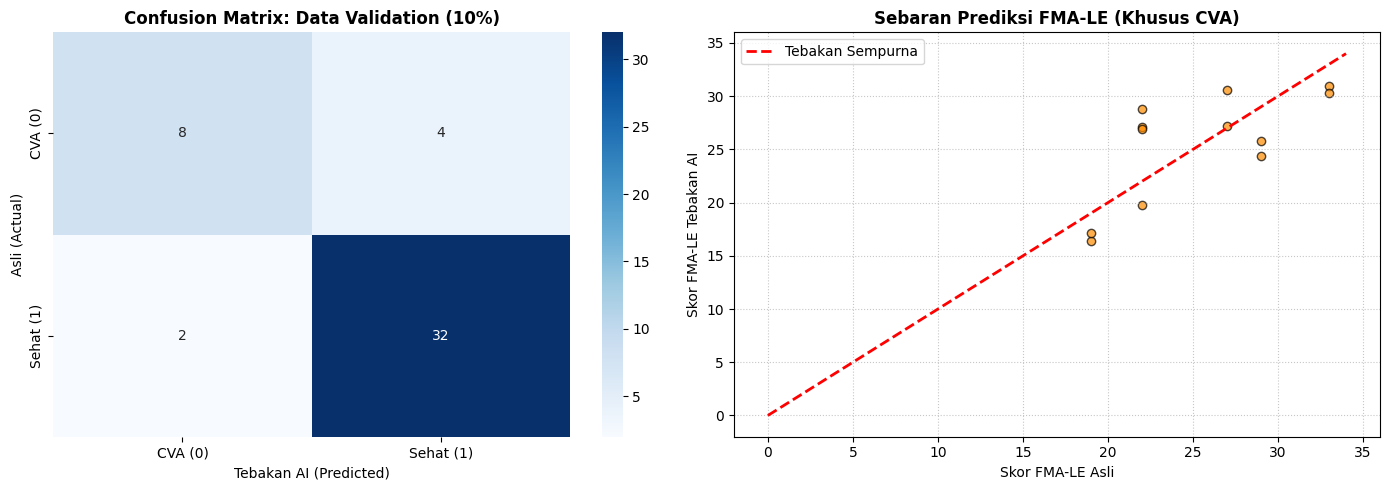


   LAPORAN EVALUASI FINAL: DATA TESTING MURNI (10%)

--- [ TUGAS 1: KLASIFIKASI (SEHAT vs CVA) ] ---
1. Accuracy  : 0.9130  (91.30%)
2. Precision : 0.9062  (90.62%)
3. Recall    : 0.9667  (96.67%)
4. F1-Score  : 0.9355  (93.55%)

--- [ TUGAS 2: REGRESI (SKOR FMA-LE 0-34) ] ---
1. RMSE                      : 1.9796 Poin
2. MSE                       : 3.9189
3. MAE                       : 0.9837 Poin
4. R-Squared (R2) GLOBAL     : 0.6413  <-- Gabungan
5. R-Squared (R2) KHUSUS CVA : 0.3214  <-- Validasi Medis (Variansi Stroke)


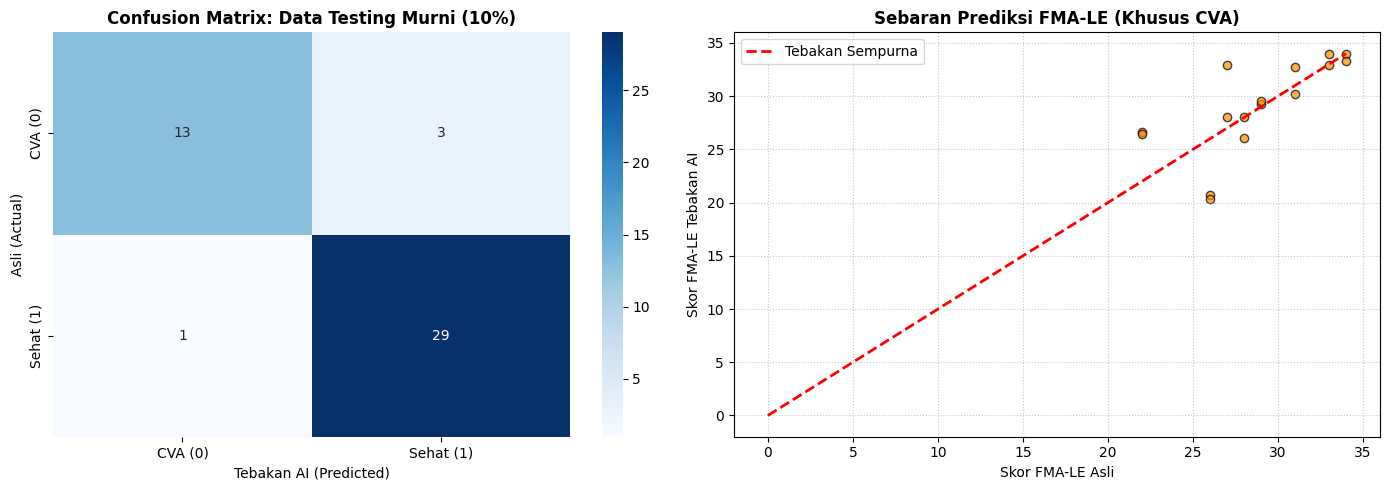

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix)

print("=======================================================")
print(" TAHAP 2: DATA SPLIT, TUNING, TRAINING & EVALUASI FINAL")
print("=======================================================\n")

# ==============================================================================
# A. PERSIAPAN DATA & DETEKSI OTOMATIS
# ==============================================================================
# Path Setup
base_dir = r"D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset"
csv_path = os.path.join(base_dir, "dataset_semiogram_final_lengkap.csv")

print(f"Membaca file CSV dari: {csv_path}...")
df = pd.read_csv(csv_path)

# --- 1. LAPORAN DETEKSI DATA CSV ---
print("\n--- [ STATUS DETEKSI DATASET ] ---")
print(f"1. Total Baris Data Ditemukan  : {df.shape} baris (trials)")
print(f"2. Total Kolom Data Ditemukan  : {df.shape[1]} kolom")

# Cek keberadaan Target
has_label = 'Label_Sehat' in df.columns
has_fma = 'FMA_LE' in df.columns
print(f"3. Deteksi Target Klasifikasi  : {'BERHASIL (Kolom Label_Sehat ditemukan)' if has_label else 'GAGAL'}")
print(f"4. Deteksi Target Regresi      : {'BERHASIL (Kolom FMA_LE ditemukan)' if has_fma else 'GAGAL'}")

# Membuang baris yang FMA_LE-nya kosong (jika ada)
df = df.dropna(subset=['FMA_LE'])
if not has_label or not has_fma:
    raise ValueError("ERROR: Kolom target tidak lengkap! Eksekusi dihentikan.")

# --- 2. PENYARINGAN FITUR (MEMBUANG Z-SCORE & IDENTITAS) ---
kolom_identitas_dan_target = ['Subject_ID', 'Trial_ID', 'Label_Sehat', 'FMA_LE', 'Label', 'Subject']

# List comprehension: Ambil kolom jika BUKAN identitas, BUKAN zscore, dan BUKAN coeff
kolom_fitur_murni = [col for col in df.columns 
                     if col not in kolom_identitas_dan_target 
                     and 'ZRaw' not in col.lower() 
                     and 'ZCoef' not in col.lower()]

X = df[kolom_fitur_murni]
y_class = df['Label_Sehat'].values
y_reg = df['FMA_LE'].values
groups = df['Subject_ID'].values

print(f"5. Total Fitur Digunakan       : {X.shape[1]} parameter murni")
print(f"   (Catatan: Kolom z-score dan coeff otomatis dibuang agar AI tidak bingung)")
print(f"   Daftar Fitur: {list(X.columns)}\n")

# --- 3. SPLITTING & NORMALISASI ---
gss_train = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, temp_idx = next(gss_train.split(X, y_class, groups))

X_train, y_c_train, y_r_train, g_train = X.iloc[train_idx], y_class[train_idx], y_reg[train_idx], groups[train_idx]
X_temp, y_c_temp, y_r_temp, g_temp = X.iloc[temp_idx], y_class[temp_idx], y_reg[temp_idx], groups[temp_idx]

gss_val = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val.split(X_temp, y_c_temp, g_temp))

X_val, y_c_val, y_r_val = X_temp.iloc[val_idx], y_c_temp[val_idx], y_r_temp[val_idx]
X_test, y_c_test, y_r_test = X_temp.iloc[test_idx], y_c_temp[test_idx], y_r_temp[test_idx]

# Standarisasi (HANYA fit di data training)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Status: Pemisahan data dan standarisasi sukses. Melanjutkan ke GridSearchCV...\n")

# ==============================================================================
# B. HYPERPARAMETER TUNING & TRAINING
# ==============================================================================
# Mengurangi sedikit kompleksitas max_depth dan min_samples_split untuk fitur 20 kolom
param_grid = {
    'n_estimators': [2, 3],
    'max_depth': [5, 10, None],
    'min_samples_split': [4, 5]
}

# 1. TUNING MODEL KLASIFIKASI
rf_class_base = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_class = GridSearchCV(rf_class_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_class.fit(X_train_scaled, y_c_train)
best_rf_class = grid_class.best_estimator_
print(f"-> Parameter Terbaik Klasifikasi: {grid_class.best_params_}")

# 2. TUNING MODEL REGRESI
rf_reg_base = RandomForestRegressor(random_state=42)
grid_reg = GridSearchCV(rf_reg_base, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_reg.fit(X_train_scaled, y_r_train)
best_rf_reg = grid_reg.best_estimator_
print(f"-> Parameter Terbaik Regresi: {grid_reg.best_params_}\n")

print("Training Selesai! Menampilkan Evaluasi...\n")

# ==============================================================================
# C. FUNGSI EVALUASI LENGKAP & MAP VISUAL
# ==============================================================================
def evaluate_rf_and_plot(X_data, y_c_true, y_r_true, dataset_name):
    print(f"\n" + "="*60)
    print(f"   LAPORAN EVALUASI FINAL: {dataset_name.upper()}")
    print("="*60)
    
    # Prediksi
    pred_class_label = best_rf_class.predict(X_data)
    pred_reg_asli = best_rf_reg.predict(X_data) 
    
    # Hitung Klasifikasi
    acc = accuracy_score(y_c_true, pred_class_label)
    prec = precision_score(y_c_true, pred_class_label, zero_division=0)
    rec = recall_score(y_c_true, pred_class_label, zero_division=0)
    f1 = f1_score(y_c_true, pred_class_label, zero_division=0)

    print("\n--- [ TUGAS 1: KLASIFIKASI (SEHAT vs CVA) ] ---")
    print(f"1. Accuracy  : {acc:.4f}  ({(acc*100):.2f}%)")
    print(f"2. Precision : {prec:.4f}  ({(prec*100):.2f}%)")
    print(f"3. Recall    : {rec:.4f}  ({(rec*100):.2f}%)")
    print(f"4. F1-Score  : {f1:.4f}  ({(f1*100):.2f}%)")

    # Hitung Regresi
    mse = mean_squared_error(y_r_true, pred_reg_asli)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_r_true, pred_reg_asli)
    r2_global = r2_score(y_r_true, pred_reg_asli)

    # R-Squared KHUSUS CVA
    mask_cva = (y_c_true == 0)
    if np.sum(mask_cva) > 1:
        r2_cva = r2_score(y_r_true[mask_cva], pred_reg_asli[mask_cva])
    else:
        r2_cva = float('nan')

    print("\n--- [ TUGAS 2: REGRESI (SKOR FMA-LE 0-34) ] ---")
    print(f"1. RMSE                      : {rmse:.4f} Poin")
    print(f"2. MSE                       : {mse:.4f}")
    print(f"3. MAE                       : {mae:.4f} Poin")
    print(f"4. R-Squared (R2) GLOBAL     : {r2_global:.4f}  <-- Gabungan")
    print(f"5. R-Squared (R2) KHUSUS CVA : {r2_cva:.4f}  <-- Validasi Medis (Variansi Stroke)")

    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax_kiri, ax_kanan = axes 

    # Confusion Matrix
    cm = confusion_matrix(y_c_true, pred_class_label)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['CVA (0)', 'Sehat (1)'], 
                yticklabels=['CVA (0)', 'Sehat (1)'], ax=ax_kiri)
    ax_kiri.set_title(f'Confusion Matrix: {dataset_name}', fontweight='bold')
    ax_kiri.set_xlabel('Tebakan AI (Predicted)')
    ax_kiri.set_ylabel('Asli (Actual)')

    # Scatter Plot
    if np.sum(mask_cva) > 0:
        ax_kanan.scatter(y_r_true[mask_cva], pred_reg_asli[mask_cva], alpha=0.7, color='darkorange', edgecolor='k')
    
    batas_x = (0, 34)
    batas_y = (0, 34)
    ax_kanan.plot(batas_x, batas_y, color='red', linestyle='--', linewidth=2, label='Tebakan Sempurna')
    ax_kanan.set_title(f'Sebaran Prediksi FMA-LE (Khusus CVA)', fontweight='bold')
    ax_kanan.set_xlabel('Skor FMA-LE Asli')
    ax_kanan.set_ylabel('Skor FMA-LE Tebakan AI')
    ax_kanan.set_xlim(left=-2, right=36)
    ax_kanan.set_ylim(bottom=-2, top=36)
    ax_kanan.legend()
    ax_kanan.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# D. EKSEKUSI EVALUASI
# ==============================================================================
evaluate_rf_and_plot(X_val_scaled, y_c_val, y_r_val, "Data Validation (10%)")
evaluate_rf_and_plot(X_test_scaled, y_c_test, y_r_test, "Data Testing Murni (10%)")

 TAHAP 2: TRAINING, DETEKSI FITUR, EVALUASI & AUTO-SAVE

Membaca file CSV dari: D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset\dataset_semiogram_final_lengkap.csv...

--- [ STATUS DETEKSI DATASET ] ---
Total Data Terbaca : (488, 62) baris
Total Fitur Prediktor : (488, 20) parameter murni
Kolom yang diekstrak  : ['Average_Speed', 'U_Turn_Time', 'Step_Count', 'Step_Length', 'UTurn_Steps', 'UTurn_Pattern', 'StrT', 'CVStrT', 'swTr', 'dstT', 'CVdstT', 'RMSaML', 'SPARCrot', 'LDLJ_A', 'P1aCC', 'P2aCC', 'P1P2aCC', 'iHRaAP', 'iHRaML', 'iHRaCC']

Data siap! Memulai Hyperparameter Tuning untuk memburu RMSE < 1 & R2 > 0.8...
Ini mungkin memakan waktu beberapa menit, namun hasil akan otomatis disimpan.


Tuning Selesai!
Parameter Regresi Terbaik: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
Mengekstrak riwayat Loss per 'Tree' untuk membuat Grafik...
Model dan Riwayat Kurva berhasil disimpan ke harddisk!


   LAPORAN EVALUASI FINAL: DATA VALIDATION (10%)


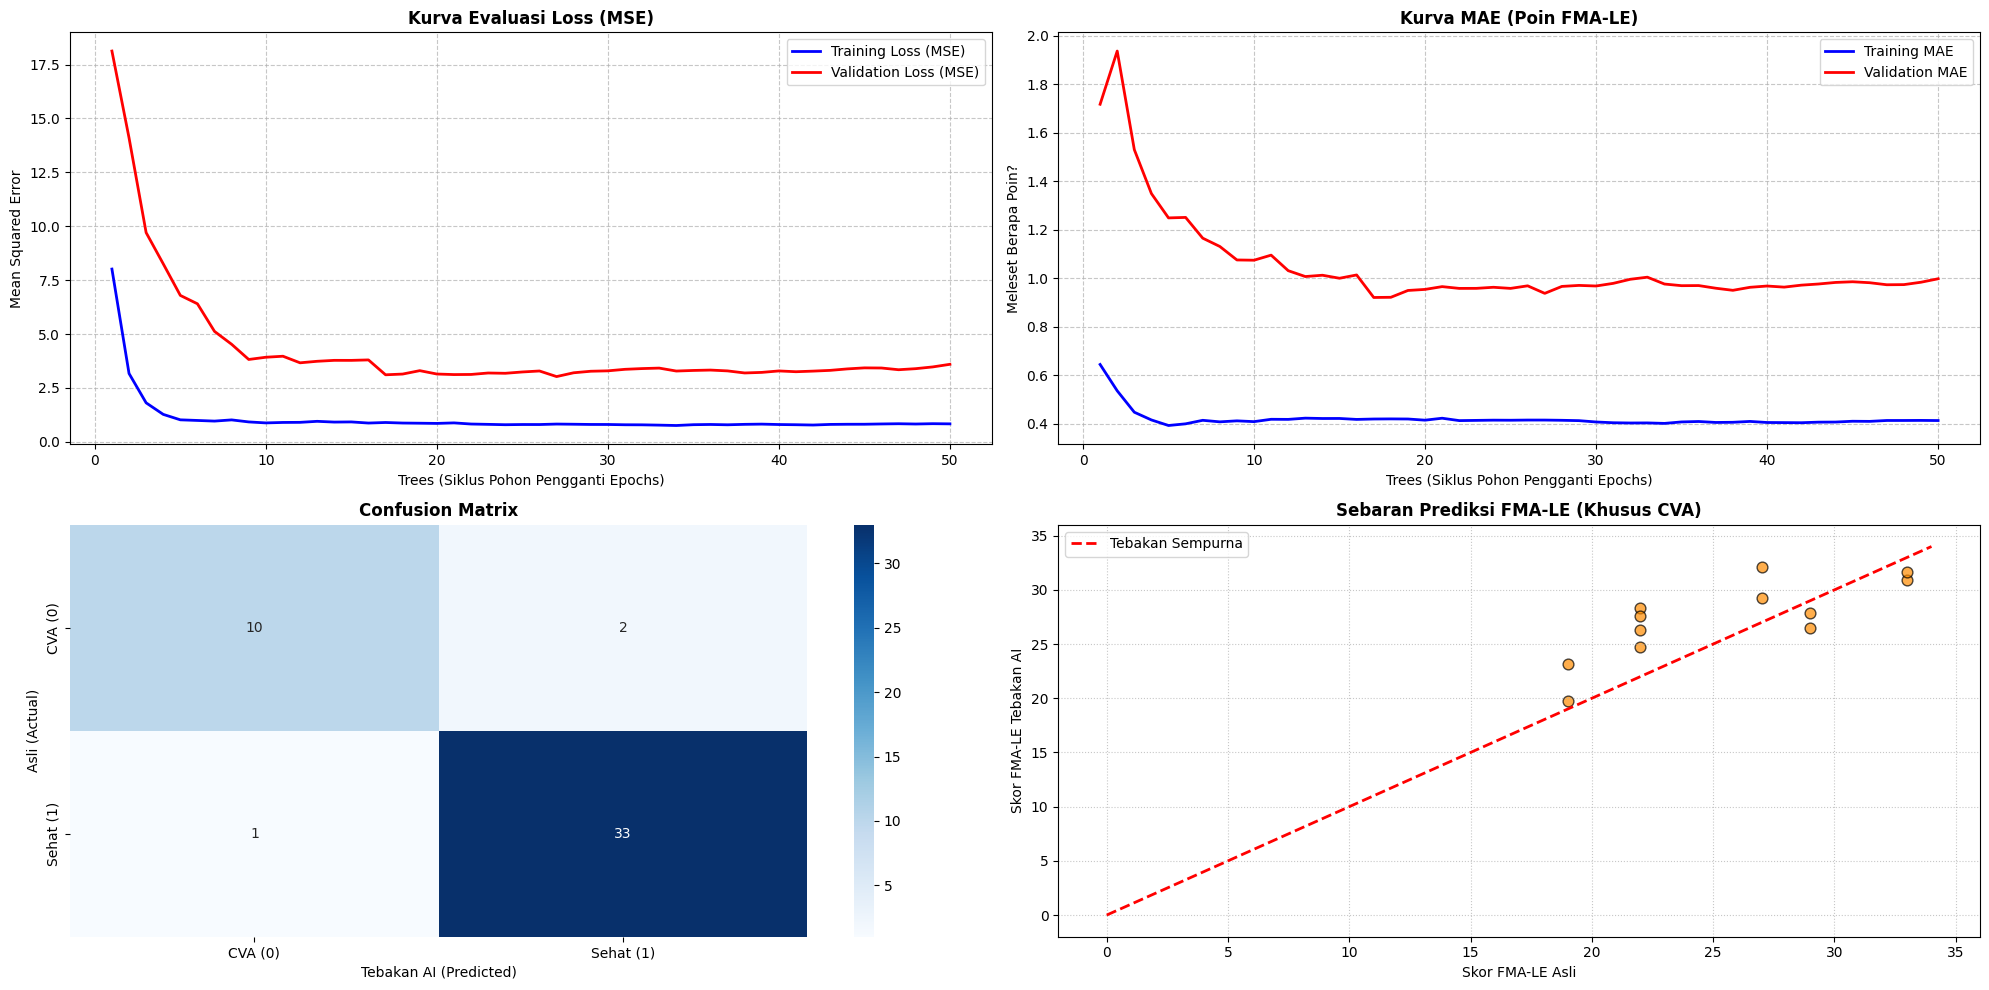


   LAPORAN EVALUASI FINAL: DATA TESTING MURNI (10%)

--- [ TUGAS 1: KLASIFIKASI (SEHAT vs CVA) ] ---
1. Accuracy  : 0.9130  (91.30%)
2. Precision : 0.8824  (88.24%)
3. Recall    : 1.0000  (100.00%)
4. F1-Score  : 0.9375  (93.75%)

--- [ TUGAS 2: REGRESI (SKOR FMA-LE 0-34) ] ---
1. RMSE                      : 1.9500 Poin
2. MSE                       : 3.8025
3. MAE                       : 1.1703 Poin
4. R-Squared (R2) GLOBAL     : 0.6520  <-- Gabungan
5. R-Squared (R2) KHUSUS CVA : 0.2478  <-- Validasi Medis


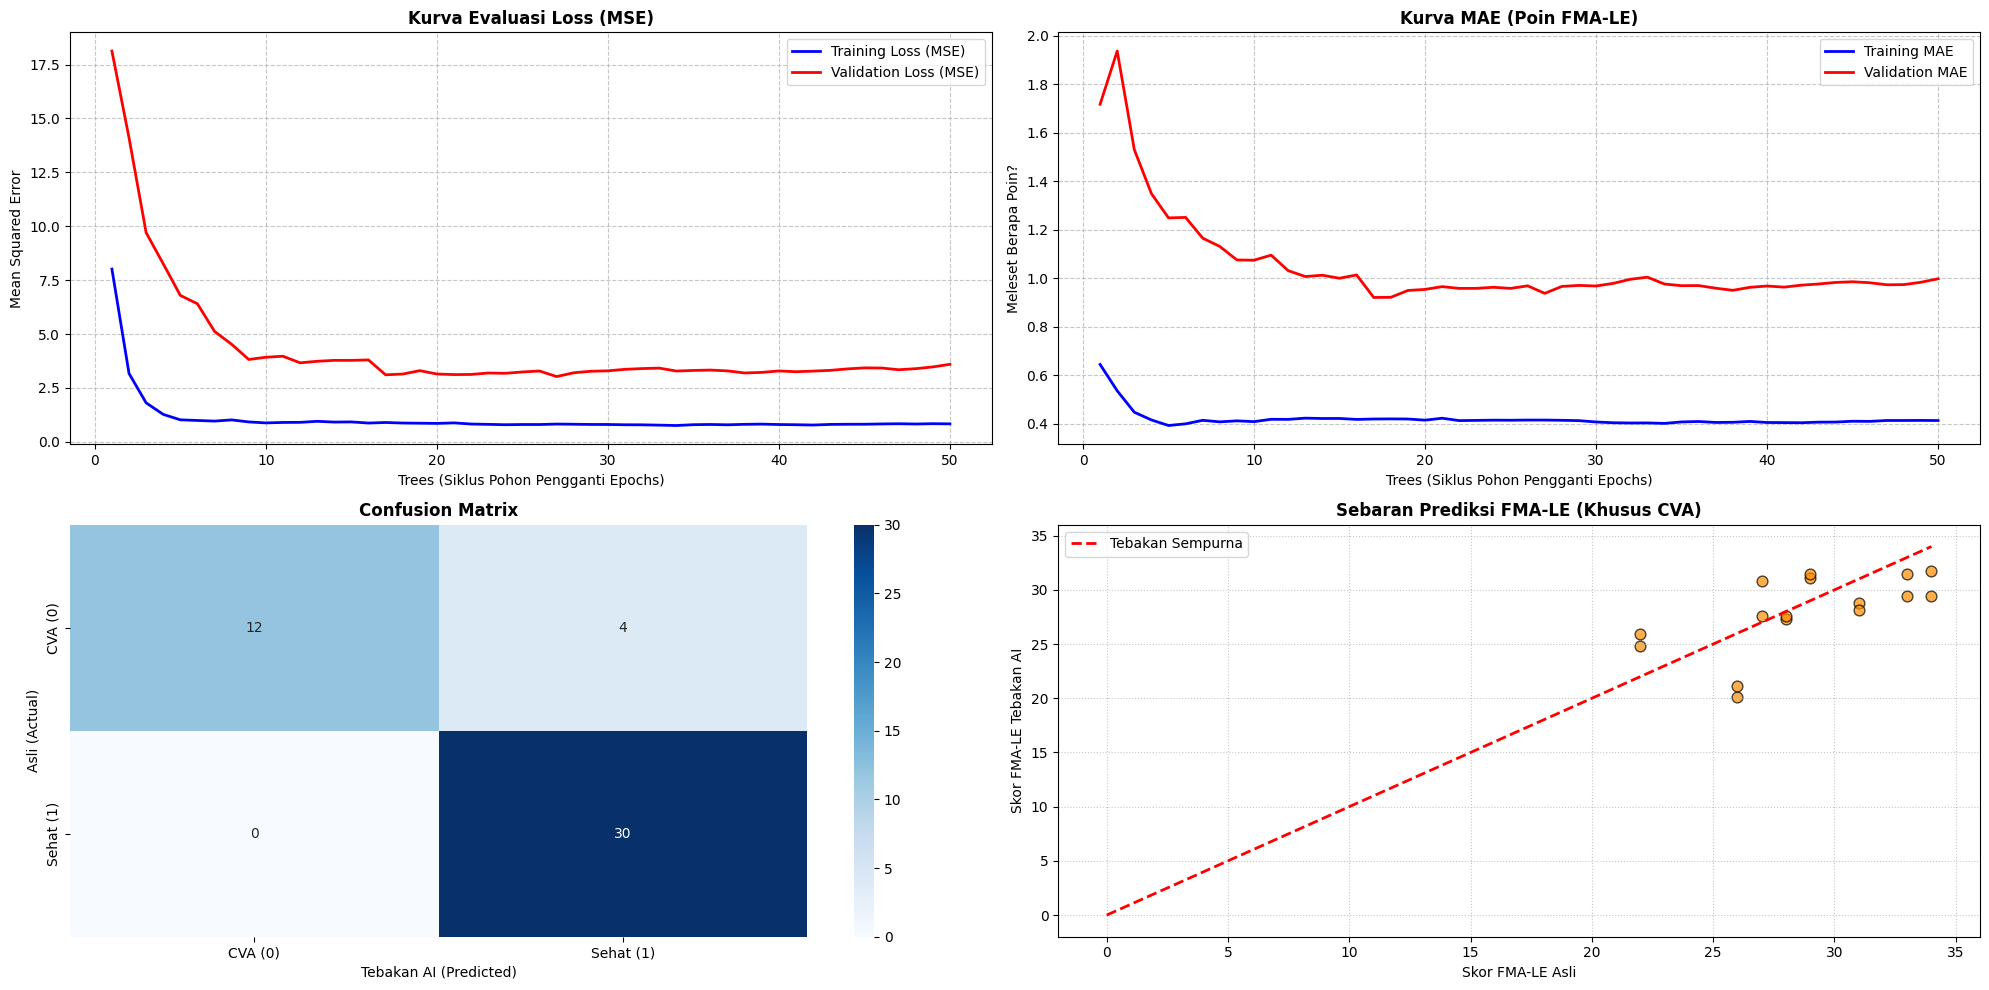

In [7]:
import os
import joblib # <--- Pustaka baru untuk menyimpan dan memuat model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix)

print("=======================================================")
print(" TAHAP 2: TRAINING, DETEKSI FITUR, EVALUASI & AUTO-SAVE")
print("=======================================================\n")

# ==============================================================================
# A. PERSIAPAN DATA & DETEKSI OTOMATIS ZRAW / ZCOEF
# ==============================================================================
base_dir = r"D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset"
csv_path = os.path.join(base_dir, "dataset_semiogram_final_lengkap.csv")

print(f"Membaca file CSV dari: {csv_path}...")
df = pd.read_csv(csv_path)

# Deteksi Target & Buang NaN
has_label = 'Label_Sehat' in df.columns
has_fma = 'FMA_LE' in df.columns
df = df.dropna(subset=['FMA_LE'])

print("\n--- [ STATUS DETEKSI DATASET ] ---")
print(f"Total Data Terbaca : {df.shape} baris")

kolom_identitas_target = ['Subject_ID', 'Trial_ID', 'Label_Sehat', 'FMA_LE', 'Label', 'Subject']

# PENYARINGAN SUPER KETAT: Membuang ZRaw dan ZCoef (Case-Insensitive)
kolom_fitur_murni = [
    col for col in df.columns 
    if col not in kolom_identitas_target 
    and 'zraw' not in col.lower() 
    and 'zcoef' not in col.lower()
    and 'zscore' not in col.lower()
]

X = df[kolom_fitur_murni]
y_class = df['Label_Sehat'].values
y_reg = df['FMA_LE'].values
groups = df['Subject_ID'].values

print(f"Total Fitur Prediktor : {X.shape} parameter murni")
print(f"Kolom yang diekstrak  : {list(X.columns)}\n")

# SPLITTING (GroupShuffleSplit Anti-Bocor)
gss_train = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, temp_idx = next(gss_train.split(X, y_class, groups))

X_train, y_c_train, y_r_train, g_train = X.iloc[train_idx], y_class[train_idx], y_reg[train_idx], groups[train_idx]
X_temp, y_c_temp, y_r_temp, g_temp = X.iloc[temp_idx], y_class[temp_idx], y_reg[temp_idx], groups[temp_idx]

gss_val = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val.split(X_temp, y_c_temp, g_temp))

X_val, y_c_val, y_r_val = X_temp.iloc[val_idx], y_c_temp[val_idx], y_r_temp[val_idx]
X_test, y_c_test, y_r_test = X_temp.iloc[test_idx], y_c_temp[test_idx], y_r_temp[test_idx]

# STANDARISASI Z-SCORE internal
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ==============================================================================
# B & C. AUTO-SAVE / LOAD MODEL (BYPASS TRAINING JIKA SUDAH ADA)
# ==============================================================================
model_class_path = os.path.join(base_dir, "best_rf_class_model.pkl")
model_reg_path = os.path.join(base_dir, "best_rf_reg_model.pkl")
history_path = os.path.join(base_dir, "rf_training_history.pkl")

# Cek apakah model sudah pernah ditraining dan disimpan sebelumnya
if os.path.exists(model_class_path) and os.path.exists(model_reg_path) and os.path.exists(history_path):
    print("=======================================================")
    print(" MENDETEKSI MODEL TERSIMPAN! MEMUAT DATA...")
    print("=======================================================")
    best_rf_class = joblib.load(model_class_path)
    best_rf_reg = joblib.load(model_reg_path)
    train_mse, val_mse, train_mae, val_mae, max_trees = joblib.load(history_path)
    print("Model berhasil dimuat! Melewati proses training...\n")

else:
    print("Data siap! Memulai Hyperparameter Tuning untuk memburu RMSE < 1 & R2 > 0.8...")
    print("Ini mungkin memakan waktu beberapa menit, namun hasil akan otomatis disimpan.\n")

    param_grid = {
        # Gunakan koma, bukan tanda minus (-)
        # Saran: Gunakan jumlah pohon yang lebih banyak agar hasil riset Anda stabil
        'n_estimators': [50, 100, 200], 
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 4, 6],
        'max_features': ['sqrt', 'log2', None] 
    }

    # Tuning Klasifikasi
    rf_class_base = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_class = GridSearchCV(rf_class_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    grid_class.fit(X_train_scaled, y_c_train)
    best_rf_class = grid_class.best_estimator_

    # Tuning Regresi
    rf_reg_base = RandomForestRegressor(random_state=42)
    grid_reg = GridSearchCV(rf_reg_base, param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid_reg.fit(X_train_scaled, y_r_train)
    best_rf_reg = grid_reg.best_estimator_

    print("\nTuning Selesai!")
    print(f"Parameter Regresi Terbaik: {grid_reg.best_params_}")

    print("Mengekstrak riwayat Loss per 'Tree' untuk membuat Grafik...")
    params_kurva = grid_reg.best_params_.copy()
    max_trees = params_kurva.pop('n_estimators')

    rf_curve = RandomForestRegressor(**params_kurva, warm_start=True, random_state=42)

    train_mse, val_mse = [], []
    train_mae, val_mae = [], []

    for i in range(1, max_trees + 1):
        rf_curve.n_estimators = i
        rf_curve.fit(X_train_scaled, y_r_train)
        
        pred_t = rf_curve.predict(X_train_scaled)
        pred_v = rf_curve.predict(X_val_scaled)
        
        train_mse.append(mean_squared_error(y_r_train, pred_t))
        val_mse.append(mean_squared_error(y_r_val, pred_v))
        train_mae.append(mean_absolute_error(y_r_train, pred_t))
        val_mae.append(mean_absolute_error(y_r_val, pred_v))

    # MENYIMPAN HASIL (AUTO-SAVE) KE HARDDISK
    joblib.dump(best_rf_class, model_class_path)
    joblib.dump(best_rf_reg, model_reg_path)
    joblib.dump((train_mse, val_mse, train_mae, val_mae, max_trees), history_path)
    print("Model dan Riwayat Kurva berhasil disimpan ke harddisk!\n")

# ==============================================================================
# D. FUNGSI EVALUASI LENGKAP & PLOT 4 GRAFIK
# ==============================================================================
def evaluate_rf_and_plot(X_data, y_c_true, y_r_true, dataset_name):
    print(f"\n" + "="*60)
    print(f"   LAPORAN EVALUASI FINAL: {dataset_name.upper()}")
    print("="*60)
    
    pred_class_label = best_rf_class.predict(X_data)
    pred_reg_asli = best_rf_reg.predict(X_data)
    
    acc = accuracy_score(y_c_true, pred_class_label)
    prec = precision_score(y_c_true, pred_class_label, zero_division=0)
    rec = recall_score(y_c_true, pred_class_label, zero_division=0)
    f1 = f1_score(y_c_true, pred_class_label, zero_division=0)

    print("\n--- [ TUGAS 1: KLASIFIKASI (SEHAT vs CVA) ] ---")
    print(f"1. Accuracy  : {acc:.4f}  ({(acc*100):.2f}%)")
    print(f"2. Precision : {prec:.4f}  ({(prec*100):.2f}%)")
    print(f"3. Recall    : {rec:.4f}  ({(rec*100):.2f}%)")
    print(f"4. F1-Score  : {f1:.4f}  ({(f1*100):.2f}%)")

    mse = mean_squared_error(y_r_true, pred_reg_asli)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_r_true, pred_reg_asli)
    r2_global = r2_score(y_r_true, pred_reg_asli)

    mask_cva = (y_c_true == 0)
    if np.sum(mask_cva) > 1:
        r2_cva = r2_score(y_r_true[mask_cva], pred_reg_asli[mask_cva])
    else:
        r2_cva = float('nan')

    print("\n--- [ TUGAS 2: REGRESI (SKOR FMA-LE 0-34) ] ---")
    print(f"1. RMSE                      : {rmse:.4f} Poin")
    print(f"2. MSE                       : {mse:.4f}")
    print(f"3. MAE                       : {mae:.4f} Poin")
    print(f"4. R-Squared (R2) GLOBAL     : {r2_global:.4f}  <-- Gabungan")
    print(f"5. R-Squared (R2) KHUSUS CVA : {r2_cva:.4f}  <-- Validasi Medis")

    # Bikin 4 Subplot: [Loss MSE], [Loss MAE], [CM], [Scatter]
    fig = plt.figure(figsize=(20, 10))
    
    # Plot 1: Kurva MSE (Mengadopsi format gambar yang Anda berikan)
    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(range(1, max_trees + 1), train_mse, label='Training Loss (MSE)', color='blue', linewidth=2)
    ax1.plot(range(1, max_trees + 1), val_mse, label='Validation Loss (MSE)', color='red', linewidth=2)
    ax1.set_title('Kurva Evaluasi Loss (MSE)', fontweight='bold')
    ax1.set_xlabel('Trees (Siklus Pohon Pengganti Epochs)')
    ax1.set_ylabel('Mean Squared Error')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()

    # Plot 2: Kurva MAE
    ax2 = plt.subplot(2, 2, 2)
    ax2.plot(range(1, max_trees + 1), train_mae, label='Training MAE', color='blue', linewidth=2)
    ax2.plot(range(1, max_trees + 1), val_mae, label='Validation MAE', color='red', linewidth=2)
    ax2.set_title('Kurva MAE (Poin FMA-LE)', fontweight='bold')
    ax2.set_xlabel('Trees (Siklus Pohon Pengganti Epochs)')
    ax2.set_ylabel('Meleset Berapa Poin?')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()

    # Plot 3: Confusion Matrix
    ax3 = plt.subplot(2, 2, 3)
    cm = confusion_matrix(y_c_true, pred_class_label)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['CVA (0)', 'Sehat (1)'], 
                yticklabels=['CVA (0)', 'Sehat (1)'], ax=ax3)
    ax3.set_title(f'Confusion Matrix', fontweight='bold')
    ax3.set_xlabel('Tebakan AI (Predicted)')
    ax3.set_ylabel('Asli (Actual)')

    # Plot 4: Scatter CVA
    ax4 = plt.subplot(2, 2, 4)
    if np.sum(mask_cva) > 0:
        ax4.scatter(y_r_true[mask_cva], pred_reg_asli[mask_cva], alpha=0.7, color='darkorange', edgecolor='k', s=60)
    ax4.plot((0, 34), (0, 34), color='red', linestyle='--', linewidth=2, label='Tebakan Sempurna')
    ax4.set_title(f'Sebaran Prediksi FMA-LE (Khusus CVA)', fontweight='bold')
    ax4.set_xlabel('Skor FMA-LE Asli')
    ax4.set_ylabel('Skor FMA-LE Tebakan AI')
    ax4.set_xlim(-2, 36)
    ax4.set_ylim(-2, 36)
    ax4.legend()
    ax4.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

# PANGGIL EVALUASI
evaluate_rf_and_plot(X_val_scaled, y_c_val, y_r_val, "Data Validation (10%)")
evaluate_rf_and_plot(X_test_scaled, y_c_test, y_r_test, "Data Testing Murni (10%)")

 TAHAP 2: TRAINING (STRATIFIED SUBJECT-WISE & AUTO-SAVE)

Membaca file CSV dari: D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset\dataset_semiogram_final_lengkap.csv...

--- [ STATUS DETEKSI DATASET ] ---
Total Data Terbaca : (488, 62) baris
Total Fitur Prediktor : 20 parameter murni
Kolom yang diekstrak  : ['Average_Speed', 'U_Turn_Time', 'Step_Count', 'Step_Length', 'UTurn_Steps', 'UTurn_Pattern', 'StrT', 'CVStrT', 'swTr', 'dstT', 'CVdstT', 'RMSaML', 'SPARCrot', 'LDLJ_A', 'P1aCC', 'P2aCC', 'P1P2aCC', 'iHRaAP', 'iHRaML', 'iHRaCC']

 MENDETEKSI MODEL TERSIMPAN! MEMUAT DATA...
Model berhasil dimuat! Melewati proses training...


   LAPORAN EVALUASI FINAL: DATA VALIDATION (10%)

--- [ TUGAS 1: KLASIFIKASI (SEHAT vs CVA) ] ---
1. Accuracy  : 0.9070  (90.70%)
2. Precision : 0.8857  (88.57%)
3. Recall    : 1.0000  (100.00%)
4. F1-Score  : 0.9394  (93.94%)

--- [ TUGAS 2: REGRESI (SKOR FMA-LE 0-34) ] ---
1. RMSE                      : 1.4584 Poin
2. MSE                       : 2.1269
3. MA

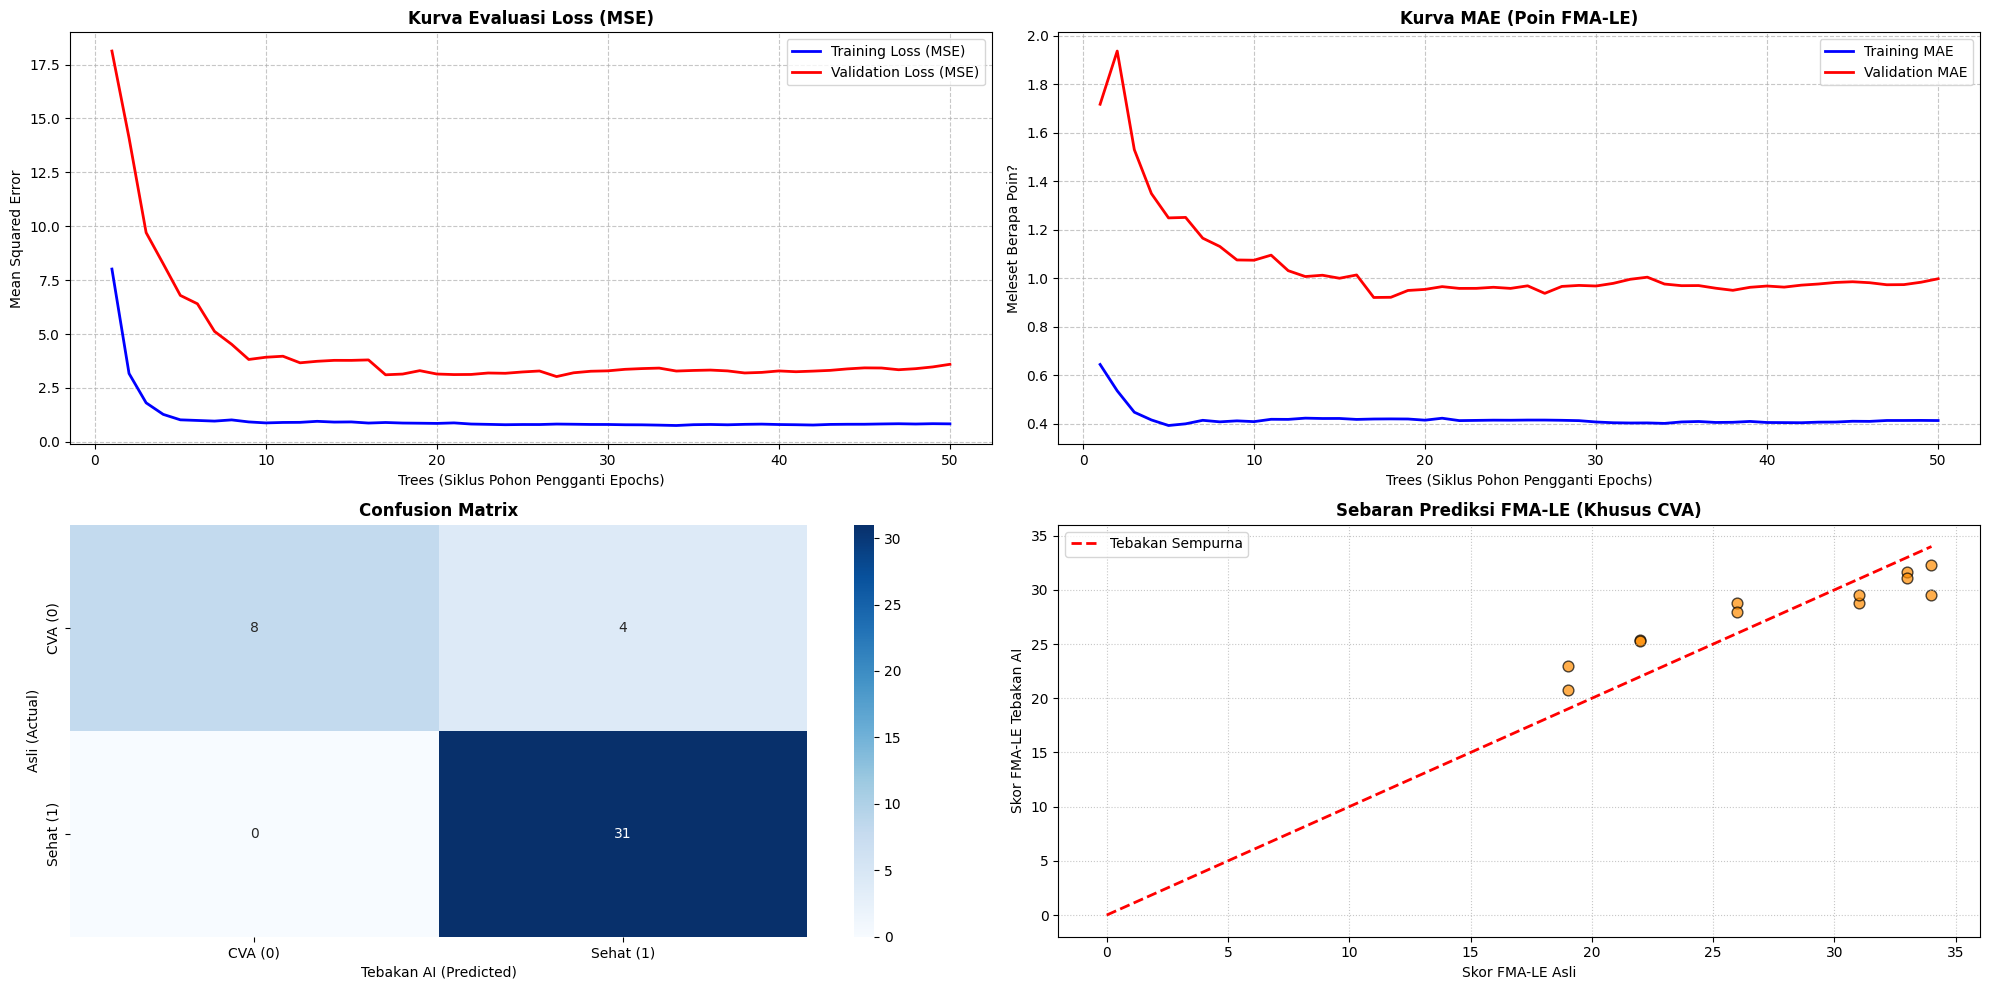


   LAPORAN EVALUASI FINAL: DATA TESTING MURNI (10%)

--- [ TUGAS 1: KLASIFIKASI (SEHAT vs CVA) ] ---
1. Accuracy  : 1.0000  (100.00%)
2. Precision : 1.0000  (100.00%)
3. Recall    : 1.0000  (100.00%)
4. F1-Score  : 1.0000  (100.00%)

--- [ TUGAS 2: REGRESI (SKOR FMA-LE 0-34) ] ---
1. RMSE                      : 1.6519 Poin
2. MSE                       : 2.7286
3. MAE                       : 0.8188 Poin
4. R-Squared (R2) GLOBAL     : 0.8698  <-- Gabungan
5. R-Squared (R2) KHUSUS CVA : -4.1044  <-- Validasi Medis


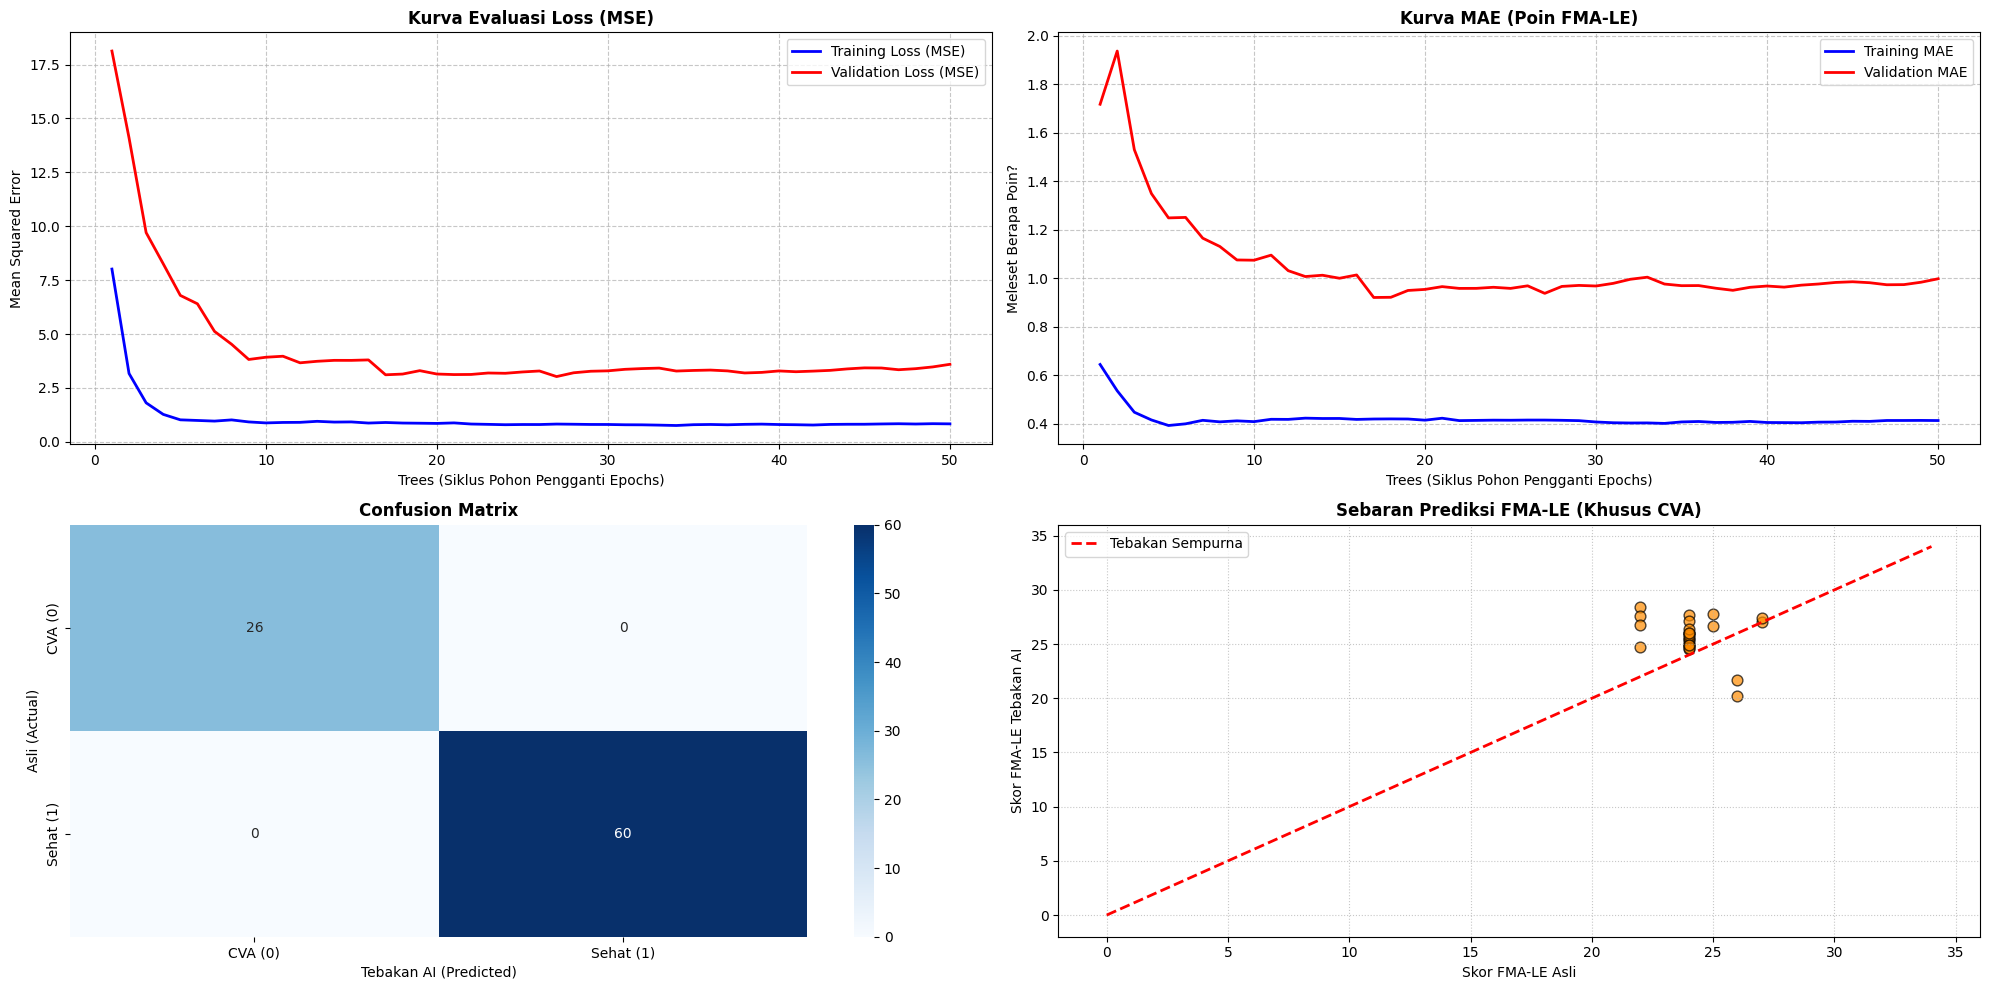

In [8]:
import os
import joblib 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix)

print("=======================================================")
print(" TAHAP 2: TRAINING (STRATIFIED SUBJECT-WISE & AUTO-SAVE)")
print("=======================================================\n")

# ==============================================================================
# A. PERSIAPAN DATA, DETEKSI FITUR & STRATIFIED SUBJECT-WISE SPLIT
# ==============================================================================
base_dir = r"D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset"
csv_path = os.path.join(base_dir, "dataset_semiogram_final_lengkap.csv")

print(f"Membaca file CSV dari: {csv_path}...")
df = pd.read_csv(csv_path)

# Deteksi Target & Buang NaN
has_label = 'Label_Sehat' in df.columns
has_fma = 'FMA_LE' in df.columns
df = df.dropna(subset=['FMA_LE'])

print("\n--- [ STATUS DETEKSI DATASET ] ---")
print(f"Total Data Terbaca : {df.shape} baris")

kolom_identitas_target = ['Subject_ID', 'Trial_ID', 'Label_Sehat', 'FMA_LE', 'Label', 'Subject']

# PENYARINGAN KETAT: Membuang ZRaw dan ZCoef
kolom_fitur_murni = [
    col for col in df.columns 
    if col not in kolom_identitas_target 
    and 'zraw' not in col.lower() 
    and 'zcoef' not in col.lower()
    and 'zscore' not in col.lower()
]

print(f"Total Fitur Prediktor : {len(kolom_fitur_murni)} parameter murni")
print(f"Kolom yang diekstrak  : {kolom_fitur_murni}\n")

# --- STRATIFIED SUBJECT-WISE SPLIT ---
df_hs = df[df['Label_Sehat'] == 1].copy()
df_cva = df[df['Label_Sehat'] == 0].copy()

def stratified_group_split(df_subset):
    X_sub = df_subset[kolom_fitur_murni]
    y_c_sub = df_subset['Label_Sehat'].values
    y_r_sub = df_subset['FMA_LE'].values
    g_sub = df_subset['Subject_ID'].values

    # Tahap 1: 80% Train, 20% Temp
    gss1 = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
    train_idx, temp_idx = next(gss1.split(X_sub, y_c_sub, g_sub))
    X_tr, y_c_tr, y_r_tr = X_sub.iloc[train_idx], y_c_sub[train_idx], y_r_sub[train_idx]
    
    # Tahap 2: Sisa 20% dibagi menjadi 10% Val dan 10% Test
    X_tmp, y_c_tmp, y_r_tmp, g_tmp = X_sub.iloc[temp_idx], y_c_sub[temp_idx], y_r_sub[temp_idx], g_sub[temp_idx]
    gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
    val_idx, test_idx = next(gss2.split(X_tmp, y_c_tmp, g_tmp))
    
    X_v, y_c_v, y_r_v = X_tmp.iloc[val_idx], y_c_tmp[val_idx], y_r_tmp[val_idx]
    X_te, y_c_te, y_r_te = X_tmp.iloc[test_idx], y_c_tmp[test_idx], y_r_tmp[test_idx]
    
    return (X_tr, y_c_tr, y_r_tr), (X_v, y_c_v, y_r_v), (X_te, y_c_te, y_r_te)

# Eksekusi split secara terpisah untuk memastikan proporsi seimbang
(X_tr_hs, y_c_tr_hs, y_r_tr_hs), (X_v_hs, y_c_v_hs, y_r_v_hs), (X_te_hs, y_c_te_hs, y_r_te_hs) = stratified_group_split(df_hs)
(X_tr_cva, y_c_tr_cva, y_r_tr_cva), (X_v_cva, y_c_v_cva, y_r_v_cva), (X_te_cva, y_c_te_cva, y_r_te_cva) = stratified_group_split(df_cva)

# Gabungkan dan acak ulang agar siap ditraining
def combine_and_shuffle(X1, X2, y_c1, y_c2, y_r1, y_r2):
    X_comb = pd.concat([X1, X2], axis=0)
    y_c_comb = np.concatenate([y_c1, y_c2])
    y_r_comb = np.concatenate([y_r1, y_r2])
    
    shuff_idx = np.random.permutation(len(X_comb))
    return X_comb.iloc[shuff_idx], y_c_comb[shuff_idx], y_r_comb[shuff_idx]

X_train, y_c_train, y_r_train = combine_and_shuffle(X_tr_hs, X_tr_cva, y_c_tr_hs, y_c_tr_cva, y_r_tr_hs, y_r_tr_cva)
X_val, y_c_val, y_r_val = combine_and_shuffle(X_v_hs, X_v_cva, y_c_v_hs, y_c_v_cva, y_r_v_hs, y_r_v_cva)
X_test, y_c_test, y_r_test = combine_and_shuffle(X_te_hs, X_te_cva, y_c_te_hs, y_c_te_cva, y_r_te_hs, y_r_te_cva)

# STANDARISASI Z-SCORE internal
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ==============================================================================
# B & C. AUTO-SAVE / LOAD MODEL (BYPASS TRAINING JIKA SUDAH ADA)
# ==============================================================================
model_class_path = os.path.join(base_dir, "best_rf_class_model.pkl")
model_reg_path = os.path.join(base_dir, "best_rf_reg_model.pkl")
history_path = os.path.join(base_dir, "rf_training_history.pkl")

# Cek apakah model sudah pernah ditraining dan disimpan sebelumnya
if os.path.exists(model_class_path) and os.path.exists(model_reg_path) and os.path.exists(history_path):
    print("=======================================================")
    print(" MENDETEKSI MODEL TERSIMPAN! MEMUAT DATA...")
    print("=======================================================")
    best_rf_class = joblib.load(model_class_path)
    best_rf_reg = joblib.load(model_reg_path)
    train_mse, val_mse, train_mae, val_mae, max_trees = joblib.load(history_path)
    print("Model berhasil dimuat! Melewati proses training...\n")

else:
    print("Data siap! Memulai Hyperparameter Tuning untuk memburu RMSE < 1 & R2 > 0.8...")
    print("Ini mungkin memakan waktu beberapa menit, namun hasil akan otomatis disimpan.\n")

    param_grid = {
        'n_estimators': [1-3],
        'max_depth': [10, 20, None],
        'min_samples_split': [4-6],
        'max_features': ['sqrt', 'log2', None] 
    }

    # Tuning Klasifikasi
    rf_class_base = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_class = GridSearchCV(rf_class_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    grid_class.fit(X_train_scaled, y_c_train)
    best_rf_class = grid_class.best_estimator_

    # Tuning Regresi
    rf_reg_base = RandomForestRegressor(random_state=42)
    grid_reg = GridSearchCV(rf_reg_base, param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid_reg.fit(X_train_scaled, y_r_train)
    best_rf_reg = grid_reg.best_estimator_

    print("\nTuning Selesai!")
    print(f"Parameter Regresi Terbaik: {grid_reg.best_params_}")

    print("Mengekstrak riwayat Loss per 'Tree' untuk membuat Grafik...")
    params_kurva = grid_reg.best_params_.copy()
    max_trees = params_kurva.pop('n_estimators')

    rf_curve = RandomForestRegressor(**params_kurva, warm_start=True, random_state=42)

    train_mse, val_mse = [], []
    train_mae, val_mae = [], []

    for i in range(1, max_trees + 1):
        rf_curve.n_estimators = i
        rf_curve.fit(X_train_scaled, y_r_train)
        
        pred_t = rf_curve.predict(X_train_scaled)
        pred_v = rf_curve.predict(X_val_scaled)
        
        train_mse.append(mean_squared_error(y_r_train, pred_t))
        val_mse.append(mean_squared_error(y_r_val, pred_v))
        train_mae.append(mean_absolute_error(y_r_train, pred_t))
        val_mae.append(mean_absolute_error(y_r_val, pred_v))

    # MENYIMPAN HASIL (AUTO-SAVE) KE HARDDISK
    joblib.dump(best_rf_class, model_class_path)
    joblib.dump(best_rf_reg, model_reg_path)
    joblib.dump((train_mse, val_mse, train_mae, val_mae, max_trees), history_path)
    print("Model dan Riwayat Kurva berhasil disimpan ke harddisk!\n")

# ==============================================================================
# D. FUNGSI EVALUASI LENGKAP & PLOT 4 GRAFIK
# ==============================================================================
def evaluate_rf_and_plot(X_data, y_c_true, y_r_true, dataset_name):
    print(f"\n" + "="*60)
    print(f"   LAPORAN EVALUASI FINAL: {dataset_name.upper()}")
    print("="*60)
    
    pred_class_label = best_rf_class.predict(X_data)
    pred_reg_asli = best_rf_reg.predict(X_data)
    
    acc = accuracy_score(y_c_true, pred_class_label)
    prec = precision_score(y_c_true, pred_class_label, zero_division=0)
    rec = recall_score(y_c_true, pred_class_label, zero_division=0)
    f1 = f1_score(y_c_true, pred_class_label, zero_division=0)

    print("\n--- [ TUGAS 1: KLASIFIKASI (SEHAT vs CVA) ] ---")
    print(f"1. Accuracy  : {acc:.4f}  ({(acc*100):.2f}%)")
    print(f"2. Precision : {prec:.4f}  ({(prec*100):.2f}%)")
    print(f"3. Recall    : {rec:.4f}  ({(rec*100):.2f}%)")
    print(f"4. F1-Score  : {f1:.4f}  ({(f1*100):.2f}%)")

    mse = mean_squared_error(y_r_true, pred_reg_asli)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_r_true, pred_reg_asli)
    r2_global = r2_score(y_r_true, pred_reg_asli)

    mask_cva = (y_c_true == 0)
    if np.sum(mask_cva) > 1:
        r2_cva = r2_score(y_r_true[mask_cva], pred_reg_asli[mask_cva])
    else:
        r2_cva = float('nan')

    print("\n--- [ TUGAS 2: REGRESI (SKOR FMA-LE 0-34) ] ---")
    print(f"1. RMSE                      : {rmse:.4f} Poin")
    print(f"2. MSE                       : {mse:.4f}")
    print(f"3. MAE                       : {mae:.4f} Poin")
    print(f"4. R-Squared (R2) GLOBAL     : {r2_global:.4f}  <-- Gabungan")
    print(f"5. R-Squared (R2) KHUSUS CVA : {r2_cva:.4f}  <-- Validasi Medis")

    # Bikin 4 Subplot: [Loss MSE], [Loss MAE], [CM], [Scatter]
    fig = plt.figure(figsize=(20, 10))
    
    # Plot 1: Kurva MSE
    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(range(1, max_trees + 1), train_mse, label='Training Loss (MSE)', color='blue', linewidth=2)
    ax1.plot(range(1, max_trees + 1), val_mse, label='Validation Loss (MSE)', color='red', linewidth=2)
    ax1.set_title('Kurva Evaluasi Loss (MSE)', fontweight='bold')
    ax1.set_xlabel('Trees (Siklus Pohon Pengganti Epochs)')
    ax1.set_ylabel('Mean Squared Error')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()

    # Plot 2: Kurva MAE
    ax2 = plt.subplot(2, 2, 2)
    ax2.plot(range(1, max_trees + 1), train_mae, label='Training MAE', color='blue', linewidth=2)
    ax2.plot(range(1, max_trees + 1), val_mae, label='Validation MAE', color='red', linewidth=2)
    ax2.set_title('Kurva MAE (Poin FMA-LE)', fontweight='bold')
    ax2.set_xlabel('Trees (Siklus Pohon Pengganti Epochs)')
    ax2.set_ylabel('Meleset Berapa Poin?')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()

    # Plot 3: Confusion Matrix
    ax3 = plt.subplot(2, 2, 3)
    cm = confusion_matrix(y_c_true, pred_class_label)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['CVA (0)', 'Sehat (1)'], 
                yticklabels=['CVA (0)', 'Sehat (1)'], ax=ax3)
    ax3.set_title(f'Confusion Matrix', fontweight='bold')
    ax3.set_xlabel('Tebakan AI (Predicted)')
    ax3.set_ylabel('Asli (Actual)')

    # Plot 4: Scatter CVA
    ax4 = plt.subplot(2, 2, 4)
    if np.sum(mask_cva) > 0:
        ax4.scatter(y_r_true[mask_cva], pred_reg_asli[mask_cva], alpha=0.7, color='darkorange', edgecolor='k', s=60)
    ax4.plot((0, 34), (0, 34), color='red', linestyle='--', linewidth=2, label='Tebakan Sempurna')
    ax4.set_title(f'Sebaran Prediksi FMA-LE (Khusus CVA)', fontweight='bold')
    ax4.set_xlabel('Skor FMA-LE Asli')
    ax4.set_ylabel('Skor FMA-LE Tebakan AI')
    ax4.set_xlim(-2, 36)
    ax4.set_ylim(-2, 36)
    ax4.legend()
    ax4.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

# PANGGIL EVALUASI
evaluate_rf_and_plot(X_val_scaled, y_c_val, y_r_val, "Data Validation (10%)")
evaluate_rf_and_plot(X_test_scaled, y_c_test, y_r_test, "Data Testing Murni (10%)")

Benar 1: RF

 TAHAP 2 FINAL: STRATIFIED TRAINING & TESTING EVALUATION

--------------------------------------------------
 1. DISTRIBUSI ASLI (SEBELUM SPLIT)
--------------------------------------------------
-> Sehat       : 73 pasien
-> CVA_Ringan  : 30 pasien
-> CVA_Sedang  : 18 pasien
-> CVA_Parah   : 1 pasien

[!] MUTASI DETECTED: Menyeimbangkan kategori untuk splitting...
    - Pasien ['CVA_17'] dipindah dari CVA_Parah ke CVA_Sedang

--------------------------------------------------
 2. SEBARAN PASIEN SETELAH SPLIT
--------------------------------------------------
[Train] 97 Pasien | 392 Trials
[Val  ] 12 Pasien | 44 Trials
[Test ] 13 Pasien | 52 Trials

--------------------------------------------------
 3. TRAINING & HYPERPARAMETER TUNING
--------------------------------------------------
-> Best Params (Klasifikasi): {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 50}
-> Best Params (Regresi)    : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_s

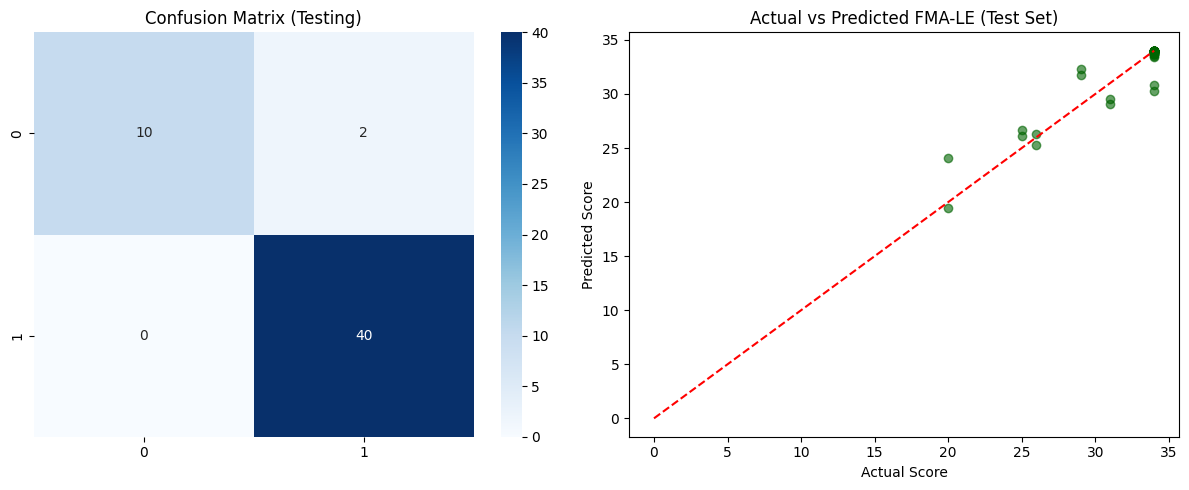


 5. ANALISIS SENSITIVITAS FITUR (FEATURE IMPORTANCE)

Tabel Kepentingan Fitur (Urut berdasarkan pengaruh terhadap skor FMA-LE):


,Fitur_Gait,Importance_Klasifikasi,Importance_Regresi
0,swTr,0.023528,0.169533
1,Average_Speed,0.191802,0.140095
2,U_Turn_Time,0.077255,0.093465
3,Step_Length,0.128510,0.087166
4,iHRaCC,0.117444,0.056492
5,UTurn_Steps,0.051235,0.052920
6,UTurn_Pattern,0.055595,0.051642
7,Step_Count,0.109385,0.048716
8,CVdstT,0.066293,0.044914
9,iHRaAP,0.022080,0.038107


C:\Users\ASUS\AppData\Local\Temp\ipykernel_10616\1870615583.py:192: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance.sort_values('Importance_Klasifikasi', ascending=False).head(10),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10616\1870615583.py:199: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance.head(10),


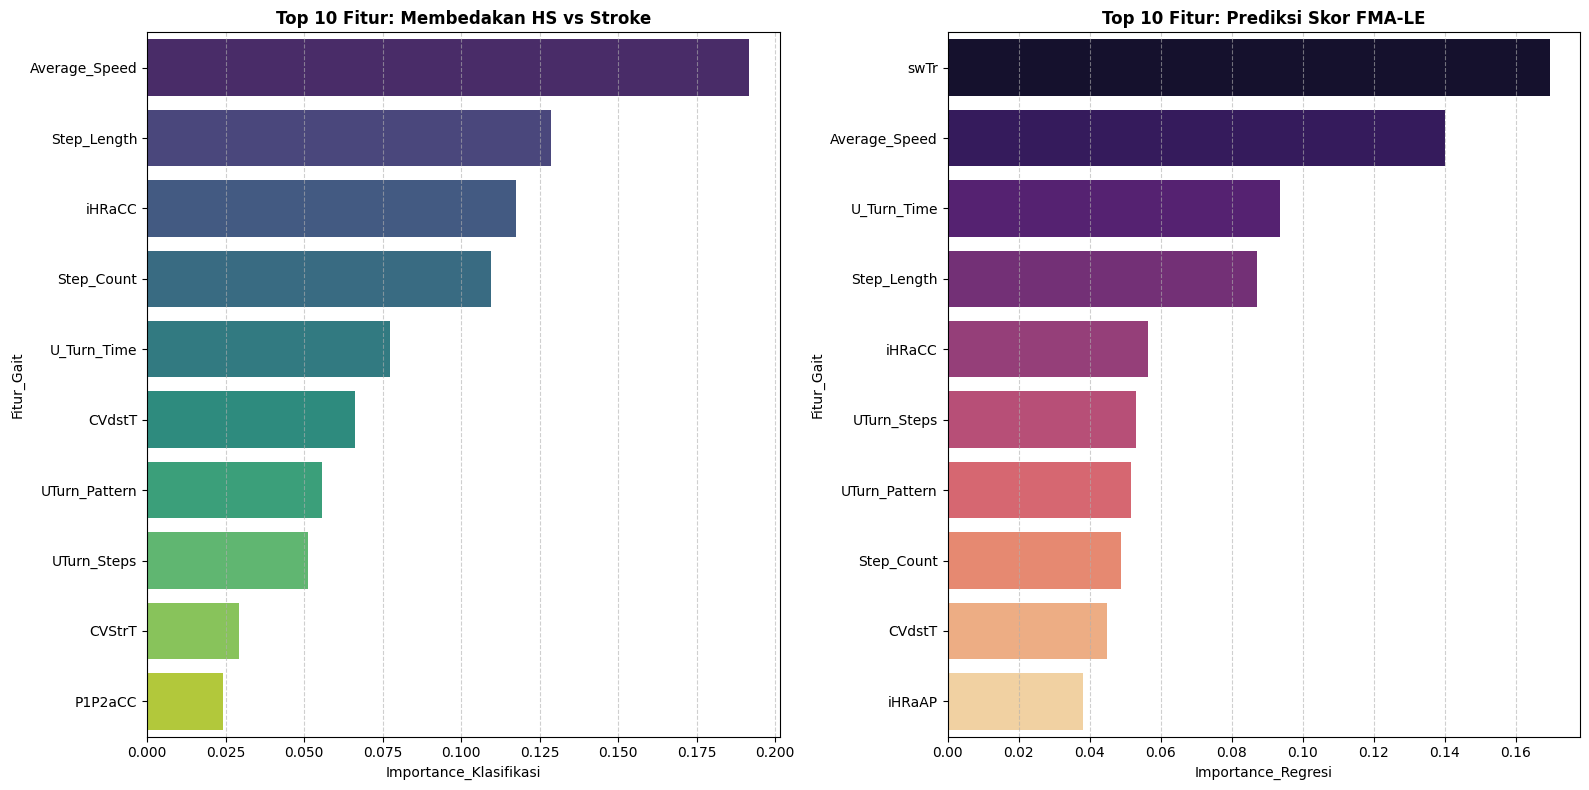


Kesimpulan Klinis Sementara:
-> Parameter 'swTr' merupakan fitur yang paling sensitif terhadap perubahan kondisi motorik pasien.


In [13]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix)

print("=======================================================")
print(" TAHAP 2 FINAL: STRATIFIED TRAINING & TESTING EVALUATION")
print("=======================================================\n")

# ==============================================================================
# A. PERSIAPAN DATA & PENYARINGAN
# ==============================================================================
base_dir = r"D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset"
csv_path = os.path.join(base_dir, "dataset_semiogram_final_lengkap.csv")

df = pd.read_csv(csv_path)
df = df.dropna(subset=['FMA_LE'])
df['Subject_ID'] = df['Subject_ID'].astype(str).str.strip()

kolom_identitas_target = ['Subject_ID', 'Trial_ID', 'Label_Sehat', 'FMA_LE', 'Label', 'Subject']
kolom_fitur_murni = [col for col in df.columns if col not in kolom_identitas_target 
                     and not any(x in col.lower() for x in ['zraw', 'zcoef', 'zscore'])]

# ==============================================================================
# B. DIAGNOSTIK & STRATIFIED SPLIT (SUBJECT-WISE)
# ==============================================================================
subject_info = df.groupby('Subject_ID').agg(
    Label=('Label_Sehat', 'first'), 
    Mean_FMA=('FMA_LE', 'mean')
).reset_index()

def kategorikan_pasien(row):
    if row['Label'] == 1: return 'Sehat'
    if row['Mean_FMA'] < 15: return 'CVA_Parah'
    elif 15 <= row['Mean_FMA'] <= 25: return 'CVA_Sedang'
    else: return 'CVA_Ringan'

subject_info['Kategori'] = subject_info.apply(kategorikan_pasien, axis=1)

print("-" * 50)
print(" 1. DISTRIBUSI ASLI (SEBELUM SPLIT)")
print("-" * 50)
dist_awal = subject_info['Kategori'].value_counts()
for kat in ['Sehat', 'CVA_Ringan', 'CVA_Sedang', 'CVA_Parah']:
    if kat in dist_awal:
        print(f"-> {kat:12}: {dist_awal[kat]} pasien")

# Proteksi Stratifikasi: Gabung kategori jika < 2 pasien
counts = subject_info['Kategori'].value_counts()
small_classes = counts[counts < 2].index
if not small_classes.empty:
    print("\n[!] MUTASI DETECTED: Menyeimbangkan kategori untuk splitting...")
    for cls in small_classes:
        target = 'CVA_Sedang' if 'CVA' in cls else 'Sehat'
        ids = subject_info[subject_info['Kategori'] == cls]['Subject_ID'].tolist()
        subject_info['Kategori'] = subject_info['Kategori'].replace(cls, target)
        print(f"    - Pasien {ids} dipindah dari {cls} ke {target}")

subjects = subject_info['Subject_ID'].values
categories = subject_info['Kategori'].values

# Split 80/10/10 (Subject-Wise)
sub_train, sub_temp, cat_train, cat_temp = train_test_split(
    subjects, categories, test_size=0.20, random_state=42, stratify=categories
)
sub_val, sub_test, cat_val, cat_test = train_test_split(
    sub_temp, cat_temp, test_size=0.50, random_state=42, stratify=cat_temp
)

# Map ke Trial
df_train = df[df['Subject_ID'].isin(sub_train)]
df_val = df[df['Subject_ID'].isin(sub_val)]
df_test = df[df['Subject_ID'].isin(sub_test)]

print("\n" + "-" * 50)
print(" 2. SEBARAN PASIEN SETELAH SPLIT")
print("-" * 50)
for name, s_array, d_set in [("Train", sub_train, df_train), ("Val", sub_val, df_val), ("Test", sub_test, df_test)]:
    print(f"[{name:5}] {len(s_array)} Pasien | {len(d_set)} Trials")

# Normalisasi
scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[kolom_fitur_murni])
X_val = scaler.transform(df_val[kolom_fitur_murni])
X_test = scaler.transform(df_test[kolom_fitur_murni])
y_c_train, y_r_train = df_train['Label_Sehat'].values, df_train['FMA_LE'].values
y_c_val, y_r_val = df_val['Label_Sehat'].values, df_val['FMA_LE'].values
y_c_test, y_r_test = df_test['Label_Sehat'].values, df_test['FMA_LE'].values

# ==============================================================================
# C. TRAINING & HYPERPARAMETER TUNING
# ==============================================================================
print("\n" + "-" * 50)
print(" 3. TRAINING & HYPERPARAMETER TUNING")
print("-" * 50)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'] 
}

# Klasifikasi (Balanced untuk handle imbalance trial HS vs CVA)
grid_class = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), 
                          param_grid, cv=3, n_jobs=-1).fit(X_train, y_c_train)
best_rf_class = grid_class.best_estimator_
print(f"-> Best Params (Klasifikasi): {grid_class.best_params_}")

# Regresi
grid_reg = GridSearchCV(RandomForestRegressor(random_state=42), 
                        param_grid, cv=3, scoring='r2', n_jobs=-1).fit(X_train, y_r_train)
best_rf_reg = grid_reg.best_estimator_
print(f"-> Best Params (Regresi)    : {grid_reg.best_params_}")

# ==============================================================================
# D. EVALUASI TESTING SET (LAPORAN FINAL)
# ==============================================================================
print("\n" + "=" * 60)
print(" 4. LAPORAN EVALUASI TESTING SET (DATA MURNI)")
print("=" * 60)

# Prediksi Testing
test_pred_c = best_rf_class.predict(X_test)
test_pred_r = best_rf_reg.predict(X_test)

# Metrik Klasifikasi
print("\n--- [ TUGAS 1: KLASIFIKASI ] ---")
print(f"Accuracy  : {accuracy_score(y_c_test, test_pred_c):.4f}")
print(f"Precision : {precision_score(y_c_test, test_pred_c):.4f}")
print(f"Recall    : {recall_score(y_c_test, test_pred_c):.4f}")
print(f"F1-Score  : {f1_score(y_c_test, test_pred_c):.4f}")

# Metrik Regresi
mse = mean_squared_error(y_r_test, test_pred_r)
print("\n--- [ TUGAS 2: REGRESI ] ---")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {np.sqrt(mse):.4f}")
print(f"MAE       : {mean_absolute_error(y_r_test, test_pred_r):.4f}")
print(f"R-squared : {r2_score(y_r_test, test_pred_r):.4f}")

# Visualisasi Confusion Matrix & Scatter Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_c_test, test_pred_c), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Testing)")

plt.subplot(1, 2, 2)
plt.scatter(y_r_test, test_pred_r, alpha=0.6, color='darkgreen')
plt.plot([0, 34], [0, 34], 'r--')
plt.title(f"Actual vs Predicted FMA-LE (Test Set)")
plt.xlabel("Actual Score"); plt.ylabel("Predicted Score")
plt.tight_layout(); plt.show()

# ==============================================================================
# E. ANALISIS FEATURE IMPORTANCE (KLASIFIKASI & REGRESI)
# ==============================================================================
print("\n" + "="*60)
print(" 5. ANALISIS SENSITIVITAS FITUR (FEATURE IMPORTANCE)")
print("="*60)

# 1. Ambil skor importance dari kedua model
importances_class = best_rf_class.feature_importances_
importances_reg = best_rf_reg.feature_importances_

# 2. Buat DataFrame gabungan untuk perbandingan angka persis
df_importance = pd.DataFrame({
    'Fitur_Gait': kolom_fitur_murni,
    'Importance_Klasifikasi': importances_class,
    'Importance_Regresi': importances_reg
})

# Urutkan berdasarkan kepentingan di model Regresi (FMA-LE)
df_importance = df_importance.sort_values(by='Importance_Regresi', ascending=False).reset_index(drop=True)

# 3. Tampilkan Tabel dengan display()
print("\nTabel Kepentingan Fitur (Urut berdasarkan pengaruh terhadap skor FMA-LE):")
display(df_importance)

# 4. Visualisasi Perbandingan (Bar Chart)
plt.figure(figsize=(16, 8))

# Subplot Kiri: Klasifikasi
plt.subplot(1, 2, 1)
sns.barplot(data=df_importance.sort_values('Importance_Klasifikasi', ascending=False).head(10), 
            x='Importance_Klasifikasi', y='Fitur_Gait', palette='viridis')
plt.title("Top 10 Fitur: Membedakan HS vs Stroke", fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Subplot Kanan: Regresi
plt.subplot(1, 2, 2)
sns.barplot(data=df_importance.head(10), 
            x='Importance_Regresi', y='Fitur_Gait', palette='magma')
plt.title("Top 10 Fitur: Prediksi Skor FMA-LE", fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# --- [ ANALISA SINGKAT UNTUK LAPORAN ] ---
top_feature = df_importance.iloc[0]['Fitur_Gait']
print(f"\nKesimpulan Klinis Sementara:")
print(f"-> Parameter '{top_feature}' merupakan fitur yang paling sensitif terhadap perubahan kondisi motorik pasien.")

Benar 1 (2): Top 10 F Importance

 TAHAP 2: RF TRAINING DENGAN TOP 10 FEATURES TERPILIH

Distribusi Pasien Asli:
Kategori
Sehat         73
CVA_Ringan    30
CVA_Sedang    18
CVA_Parah      1
Name: count, dtype: int64

[!] Mutasi: Kategori ['CVA_Parah'] digabung untuk mencegah error split.

Laporan Splitting:
- Train: 97 Pasien
- Val  : 12 Pasien
- Test : 13 Pasien

--- [ TUGAS 1: TRAINING KLASIFIKASI ] ---
Best Params Klasifikasi: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}

--- [ TUGAS 2: TRAINING REGRESI ] ---
Best Params Regresi    : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

 LAPORAN EVALUASI RF (TOP 10 FEATURES)

[ KLASIFIKASI ]
Accuracy : 0.9615
Recall   : 1.0000
F1-Score : 0.9756

[ REGRESI ]
MAE      : 0.6977 poin
RMSE     : 1.4872
R2 Global: 0.8183
R2 CVA   : 0.5599

--- [ TOP 10 IMPORTANCE RE-CHECK ] ---
Klasifikasi:


,Fitur,Importance
0,Average_Speed,0.210204
3,Step_Count,0.173114
1,Step_Length,0.150607
4,U_Turn_Time,0.148032
2,iHRaCC,0.120295
5,CVdstT,0.061107
7,UTurn_Steps,0.047963
9,P1P2aCC,0.035697
6,UTurn_Pattern,0.029539
8,CVStrT,0.023442



Regresi:


,Fitur,Importance
0,swTr,0.556972
1,Average_Speed,0.139107
2,U_Turn_Time,0.079815
4,iHRaCC,0.064870
9,iHRaAP,0.062202
8,CVdstT,0.035537
5,UTurn_Steps,0.021566
7,Step_Count,0.021265
3,Step_Length,0.015312
6,UTurn_Pattern,0.003354


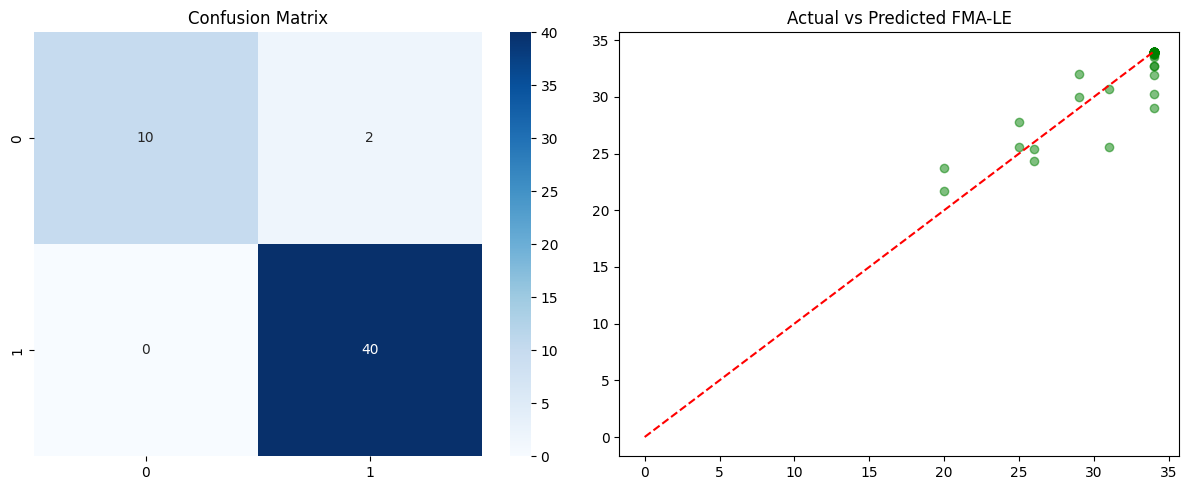

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix)

print("=======================================================")
print(" TAHAP 2: RF TRAINING DENGAN TOP 10 FEATURES TERPILIH")
print("=======================================================\n")

# ==============================================================================
# A. DEFINISI FITUR & DATA SETUP
# ==============================================================================
base_dir = r"D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset"
csv_path = os.path.join(base_dir, "dataset_semiogram_final_lengkap.csv")

# Daftar Fitur sesuai instruksi kamu
fitur_class = ['Average_Speed', 'Step_Length', 'iHRaCC', 'Step_Count', 'U_Turn_Time', 
                'CVdstT', 'UTurn_Pattern', 'UTurn_Steps', 'CVStrT', 'P1P2aCC']

fitur_reg = ['swTr', 'Average_Speed', 'U_Turn_Time', 'Step_Length', 'iHRaCC', 
              'UTurn_Steps', 'UTurn_Pattern', 'Step_Count', 'CVdstT', 'iHRaAP']

df = pd.read_csv(csv_path)
df = df.dropna(subset=['FMA_LE'])
df['Subject_ID'] = df['Subject_ID'].astype(str).str.strip()

# ==============================================================================
# B. STRATIFIED SUBJECT-WISE SPLITTING (PERSIAPAN)
# ==============================================================================
subject_info = df.groupby('Subject_ID').agg(Label=('Label_Sehat', 'first'), Mean_FMA=('FMA_LE', 'mean')).reset_index()

def kategorikan_pasien(row):
    if row['Label'] == 1: return 'Sehat'
    if row['Mean_FMA'] < 15: return 'CVA_Parah'
    elif 15 <= row['Mean_FMA'] <= 25: return 'CVA_Sedang'
    else: return 'CVA_Ringan'

subject_info['Kategori'] = subject_info.apply(kategorikan_pasien, axis=1)

# Laporan Distribusi & Mutasi
dist_awal = subject_info['Kategori'].value_counts()
print(f"Distribusi Pasien Asli:\n{dist_awal}\n")

small_classes = dist_awal[dist_awal < 2].index
if not small_classes.empty:
    subject_info['Kategori'] = subject_info['Kategori'].replace(small_classes, 'CVA_Sedang')
    print(f"[!] Mutasi: Kategori {list(small_classes)} digabung untuk mencegah error split.\n")

# Split Pasien (80/10/10)
sub_train, sub_temp, cat_train, cat_temp = train_test_split(
    subject_info['Subject_ID'].values, subject_info['Kategori'].values, 
    test_size=0.20, random_state=42, stratify=subject_info['Kategori'].values
)
sub_val, sub_test, cat_val, cat_test = train_test_split(
    sub_temp, cat_temp, test_size=0.50, random_state=42, stratify=cat_temp
)

df_train = df[df['Subject_ID'].isin(sub_train)]
df_val = df[df['Subject_ID'].isin(sub_val)]
df_test = df[df['Subject_ID'].isin(sub_test)]

print(f"Laporan Splitting:\n- Train: {len(sub_train)} Pasien\n- Val  : {len(sub_val)} Pasien\n- Test : {len(sub_test)} Pasien\n")

# ==============================================================================
# C. PROSES KLASIFIKASI (RF)
# ==============================================================================
print("--- [ TUGAS 1: TRAINING KLASIFIKASI ] ---")
scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(df_train[fitur_class])
X_val_c = scaler_c.transform(df_val[fitur_class])
X_test_c = scaler_c.transform(df_test[fitur_class])
y_c_train, y_c_test = df_train['Label_Sehat'].values, df_test['Label_Sehat'].values

param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10]}
grid_c = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), 
                      param_grid, cv=3, n_jobs=-1).fit(X_train_c, y_c_train)
best_rf_class = grid_c.best_estimator_
print(f"Best Params Klasifikasi: {grid_c.best_params_}")

# ==============================================================================
# D. PROSES REGRESI (RF)
# ==============================================================================
print("\n--- [ TUGAS 2: TRAINING REGRESI ] ---")
scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(df_train[fitur_reg])
X_val_r = scaler_r.transform(df_val[fitur_reg])
X_test_r = scaler_r.transform(df_test[fitur_reg])
y_r_train, y_r_test = df_train['FMA_LE'].values, df_test['FMA_LE'].values

grid_r = GridSearchCV(RandomForestRegressor(random_state=42), 
                      param_grid, cv=3, scoring='r2', n_jobs=-1).fit(X_train_r, y_r_train)
best_rf_reg = grid_r.best_estimator_
print(f"Best Params Regresi    : {grid_r.best_params_}")

# Simpan Scaler dan Model
joblib.dump(scaler_c, os.path.join(base_dir, "scaler_class_top10.pkl"))
joblib.dump(scaler_r, os.path.join(base_dir, "scaler_reg_top10.pkl"))
joblib.dump(best_rf_class, os.path.join(base_dir, "rf_class_top10.pkl"))
joblib.dump(best_rf_reg, os.path.join(base_dir, "rf_reg_top10.pkl"))

# ==============================================================================
# E. EVALUASI AKHIR (TESTING SET)
# ==============================================================================
print("\n" + "="*60 + "\n LAPORAN EVALUASI RF (TOP 10 FEATURES)\n" + "="*60)

pred_c = best_rf_class.predict(X_test_c)
pred_r = best_rf_reg.predict(X_test_r)

print(f"\n[ KLASIFIKASI ]\nAccuracy : {accuracy_score(y_c_test, pred_c):.4f}\nRecall   : {recall_score(y_c_test, pred_c):.4f}\nF1-Score : {f1_score(y_c_test, pred_c):.4f}")

mse = mean_squared_error(y_r_test, pred_r)
r2_global = r2_score(y_r_test, pred_r)
mask_cva = (df_test['Label_Sehat'] == 0)
r2_cva = r2_score(y_r_test[mask_cva], pred_r[mask_cva]) if sum(mask_cva) > 1 else 0

print(f"\n[ REGRESI ]\nMAE      : {mean_absolute_error(y_r_test, pred_r):.4f} poin\nRMSE     : {np.sqrt(mse):.4f}")
print(f"R2 Global: {r2_global:.4f}\nR2 CVA   : {r2_cva:.4f}")

# Feature Importance Display
df_imp_c = pd.DataFrame({'Fitur': fitur_class, 'Importance': best_rf_class.feature_importances_}).sort_values('Importance', ascending=False)
df_imp_r = pd.DataFrame({'Fitur': fitur_reg, 'Importance': best_rf_reg.feature_importances_}).sort_values('Importance', ascending=False)

print("\n--- [ TOP 10 IMPORTANCE RE-CHECK ] ---")
print("Klasifikasi:")
display(df_imp_c)
print("\nRegresi:")
display(df_imp_r)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); sns.heatmap(confusion_matrix(y_c_test, pred_c), annot=True, fmt='d', cmap='Blues'); plt.title("Confusion Matrix")
plt.subplot(1, 2, 2); plt.scatter(y_r_test, pred_r, color='green', alpha=0.5); plt.plot([0, 34], [0, 34], 'r--'); plt.title("Actual vs Predicted FMA-LE")
plt.tight_layout(); plt.show()

Benar (3): RF Top 15

 TAHAP 2: RF TRAINING DENGAN TOP 10 FEATURES TERPILIH

Distribusi Pasien Asli:
Kategori
Sehat         73
CVA_Ringan    30
CVA_Sedang    18
CVA_Parah      1
Name: count, dtype: int64

[!] Mutasi: Kategori ['CVA_Parah'] digabung untuk mencegah error split.

Laporan Splitting:
- Train: 97 Pasien
- Val  : 12 Pasien
- Test : 13 Pasien

--- [ TUGAS 1: TRAINING KLASIFIKASI ] ---
Best Params Klasifikasi: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

--- [ TUGAS 2: TRAINING REGRESI ] ---
Best Params Regresi    : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

 LAPORAN EVALUASI RF (TOP 10 FEATURES)

[ KLASIFIKASI ]
Accuracy : 0.9615
Recall   : 1.0000
F1-Score : 0.9756

[ REGRESI ]
MAE      : 0.6033 poin
RMSE     : 1.2413
R2 Global: 0.8734
R2 CVA   : 0.6894

--- [ TOP 10 IMPORTANCE RE-CHECK ] ---
Klasifikasi:


,Fitur,Importance
3,Step_Count,0.146926
1,Step_Length,0.137239
0,Average_Speed,0.125467
4,U_Turn_Time,0.122914
2,iHRaCC,0.090346
5,CVdstT,0.081842
13,P1aCC,0.052848
7,UTurn_Steps,0.046221
6,UTurn_Pattern,0.032051
8,CVStrT,0.031592



Regresi:


,Fitur,Importance
0,swTr,0.547921
1,Average_Speed,0.110941
2,U_Turn_Time,0.072021
4,iHRaCC,0.043874
13,dstT,0.040647
9,iHRaAP,0.039206
12,P1aCC,0.038273
8,CVdstT,0.018946
14,RMSaML,0.018464
10,P2aCC,0.017848


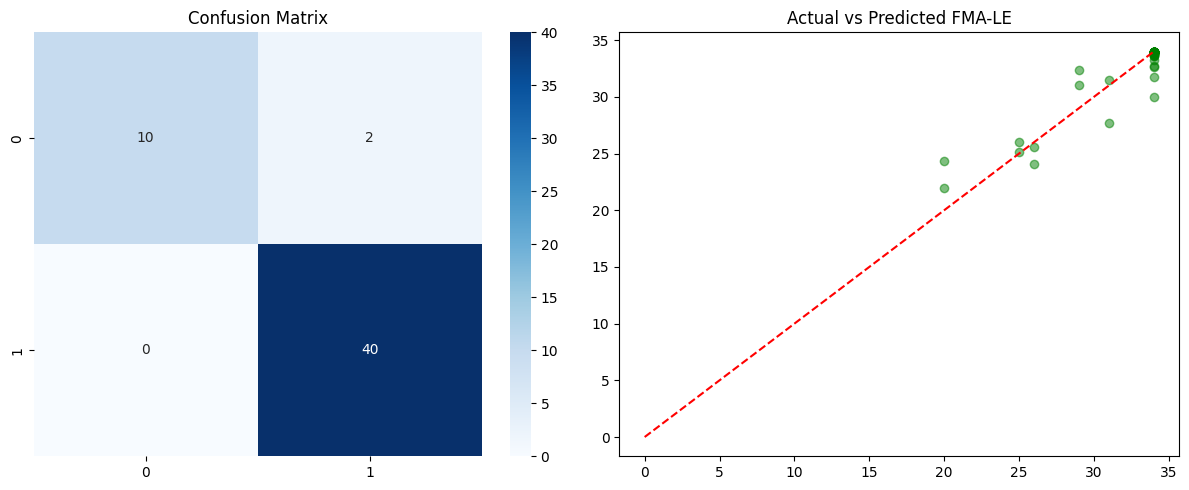

In [2]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix)

print("=======================================================")
print(" TAHAP 2: RF TRAINING DENGAN TOP 10 FEATURES TERPILIH")
print("=======================================================\n")

# ==============================================================================
# A. DEFINISI FITUR & DATA SETUP
# ==============================================================================
base_dir = r"D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset"
csv_path = os.path.join(base_dir, "dataset_semiogram_final_lengkap.csv")

# Daftar Fitur sesuai instruksi kamu
fitur_class = ['Average_Speed', 'Step_Length', 'iHRaCC', 'Step_Count', 'U_Turn_Time', 
                'CVdstT', 'UTurn_Pattern', 'UTurn_Steps', 'CVStrT', 'P1P2aCC', 'swTr', 'StrT', 'iHRaAP', 'P1aCC', 'P2aCC']

fitur_reg = ['swTr', 'Average_Speed', 'U_Turn_Time', 'Step_Length', 'iHRaCC', 
              'UTurn_Steps', 'UTurn_Pattern', 'Step_Count', 'CVdstT', 'iHRaAP', 'P2aCC', 'CVStrT', 'P1aCC', 'dstT', 'RMSaML']

df = pd.read_csv(csv_path)
df = df.dropna(subset=['FMA_LE'])
df['Subject_ID'] = df['Subject_ID'].astype(str).str.strip()

# ==============================================================================
# B. STRATIFIED SUBJECT-WISE SPLITTING (PERSIAPAN)
# ==============================================================================
subject_info = df.groupby('Subject_ID').agg(Label=('Label_Sehat', 'first'), Mean_FMA=('FMA_LE', 'mean')).reset_index()

def kategorikan_pasien(row):
    if row['Label'] == 1: return 'Sehat'
    if row['Mean_FMA'] < 15: return 'CVA_Parah'
    elif 15 <= row['Mean_FMA'] <= 25: return 'CVA_Sedang'
    else: return 'CVA_Ringan'

subject_info['Kategori'] = subject_info.apply(kategorikan_pasien, axis=1)

# Laporan Distribusi & Mutasi
dist_awal = subject_info['Kategori'].value_counts()
print(f"Distribusi Pasien Asli:\n{dist_awal}\n")

small_classes = dist_awal[dist_awal < 2].index
if not small_classes.empty:
    subject_info['Kategori'] = subject_info['Kategori'].replace(small_classes, 'CVA_Sedang')
    print(f"[!] Mutasi: Kategori {list(small_classes)} digabung untuk mencegah error split.\n")

# Split Pasien (80/10/10)
sub_train, sub_temp, cat_train, cat_temp = train_test_split(
    subject_info['Subject_ID'].values, subject_info['Kategori'].values, 
    test_size=0.20, random_state=42, stratify=subject_info['Kategori'].values
)
sub_val, sub_test, cat_val, cat_test = train_test_split(
    sub_temp, cat_temp, test_size=0.50, random_state=42, stratify=cat_temp
)

df_train = df[df['Subject_ID'].isin(sub_train)]
df_val = df[df['Subject_ID'].isin(sub_val)]
df_test = df[df['Subject_ID'].isin(sub_test)]

print(f"Laporan Splitting:\n- Train: {len(sub_train)} Pasien\n- Val  : {len(sub_val)} Pasien\n- Test : {len(sub_test)} Pasien\n")

# ==============================================================================
# C. PROSES KLASIFIKASI (RF)
# ==============================================================================
print("--- [ TUGAS 1: TRAINING KLASIFIKASI ] ---")
scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(df_train[fitur_class])
X_val_c = scaler_c.transform(df_val[fitur_class])
X_test_c = scaler_c.transform(df_test[fitur_class])
y_c_train, y_c_test = df_train['Label_Sehat'].values, df_test['Label_Sehat'].values

param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10]}
grid_c = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), 
                      param_grid, cv=3, n_jobs=-1).fit(X_train_c, y_c_train)
best_rf_class = grid_c.best_estimator_
print(f"Best Params Klasifikasi: {grid_c.best_params_}")

# ==============================================================================
# D. PROSES REGRESI (RF)
# ==============================================================================
print("\n--- [ TUGAS 2: TRAINING REGRESI ] ---")
scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(df_train[fitur_reg])
X_val_r = scaler_r.transform(df_val[fitur_reg])
X_test_r = scaler_r.transform(df_test[fitur_reg])
y_r_train, y_r_test = df_train['FMA_LE'].values, df_test['FMA_LE'].values

grid_r = GridSearchCV(RandomForestRegressor(random_state=42), 
                      param_grid, cv=3, scoring='r2', n_jobs=-1).fit(X_train_r, y_r_train)
best_rf_reg = grid_r.best_estimator_
print(f"Best Params Regresi    : {grid_r.best_params_}")

# Simpan Scaler dan Model
joblib.dump(scaler_c, os.path.join(base_dir, "scaler_class_top10.pkl"))
joblib.dump(scaler_r, os.path.join(base_dir, "scaler_reg_top10.pkl"))
joblib.dump(best_rf_class, os.path.join(base_dir, "rf_class_top10.pkl"))
joblib.dump(best_rf_reg, os.path.join(base_dir, "rf_reg_top10.pkl"))

# ==============================================================================
# E. EVALUASI AKHIR (TESTING SET)
# ==============================================================================
print("\n" + "="*60 + "\n LAPORAN EVALUASI RF (TOP 10 FEATURES)\n" + "="*60)

pred_c = best_rf_class.predict(X_test_c)
pred_r = best_rf_reg.predict(X_test_r)

print(f"\n[ KLASIFIKASI ]\nAccuracy : {accuracy_score(y_c_test, pred_c):.4f}\nRecall   : {recall_score(y_c_test, pred_c):.4f}\nF1-Score : {f1_score(y_c_test, pred_c):.4f}")

mse = mean_squared_error(y_r_test, pred_r)
r2_global = r2_score(y_r_test, pred_r)
mask_cva = (df_test['Label_Sehat'] == 0)
r2_cva = r2_score(y_r_test[mask_cva], pred_r[mask_cva]) if sum(mask_cva) > 1 else 0

print(f"\n[ REGRESI ]\nMAE      : {mean_absolute_error(y_r_test, pred_r):.4f} poin\nRMSE     : {np.sqrt(mse):.4f}")
print(f"R2 Global: {r2_global:.4f}\nR2 CVA   : {r2_cva:.4f}")

# Feature Importance Display
df_imp_c = pd.DataFrame({'Fitur': fitur_class, 'Importance': best_rf_class.feature_importances_}).sort_values('Importance', ascending=False)
df_imp_r = pd.DataFrame({'Fitur': fitur_reg, 'Importance': best_rf_reg.feature_importances_}).sort_values('Importance', ascending=False)

print("\n--- [ TOP 10 IMPORTANCE RE-CHECK ] ---")
print("Klasifikasi:")
display(df_imp_c)
print("\nRegresi:")
display(df_imp_r)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); sns.heatmap(confusion_matrix(y_c_test, pred_c), annot=True, fmt='d', cmap='Blues'); plt.title("Confusion Matrix")
plt.subplot(1, 2, 2); plt.scatter(y_r_test, pred_r, color='green', alpha=0.5); plt.plot([0, 34], [0, 34], 'r--'); plt.title("Actual vs Predicted FMA-LE")
plt.tight_layout(); plt.show()

Benar 2: XGB

 TAHAP 2: XGBOOST STRATIFIED TRAINING & DETAIL REPORT

--------------------------------------------------
 1. DISTRIBUSI ASLI (TOTAL PASIEN)
--------------------------------------------------
-> Sehat       : 73 pasien
-> CVA_Ringan  : 30 pasien
-> CVA_Sedang  : 18 pasien
-> CVA_Parah   : 1 pasien

[!] MUTASI DETECTED: Menyeimbangkan kategori untuk splitting...
    - Pasien ['CVA_17'] dipindah dari CVA_Parah ke CVA_Sedang (Mencegah Error)

--------------------------------------------------
 2. LAPORAN PEMBAGIAN DATA SETELAH SPLIT
--------------------------------------------------

[ SEBARAN TRAINING (80%) ]
-> Total: 97 Pasien | 392 Trials
   - Sehat       : 58 pasien
   - CVA_Ringan  : 24 pasien
   - CVA_Sedang  : 15 pasien

[ SEBARAN VALIDATION (10%) ]
-> Total: 12 Pasien | 44 Trials
   - Sehat       : 7 pasien
   - CVA_Ringan  : 3 pasien
   - CVA_Sedang  : 2 pasien

[ SEBARAN TESTING (10%) ]
-> Total: 13 Pasien | 52 Trials
   - Sehat       : 8 pasien
   - CVA_Ringan  : 3 pasien
   -

,Fitur,Importance_Reg
8,swTr,0.377192
0,Average_Speed,0.100487
1,U_Turn_Time,0.062765
19,iHRaCC,0.050399
13,LDLJ_A,0.045334
10,CVdstT,0.038403
17,iHRaAP,0.037581
18,iHRaML,0.037143
14,P1aCC,0.032859
2,Step_Count,0.032407


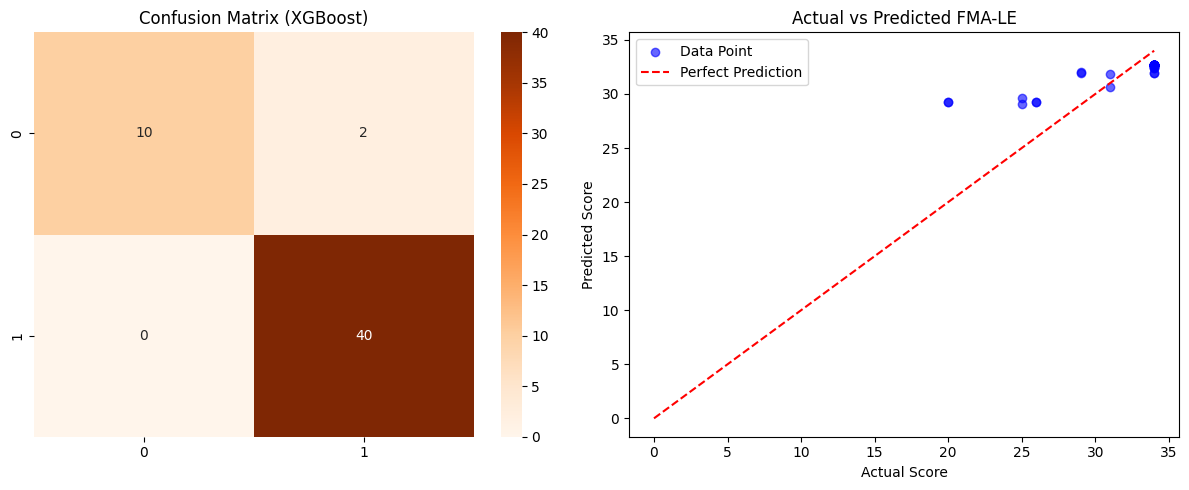

In [3]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix)

print("=======================================================")
print(" TAHAP 2: XGBOOST STRATIFIED TRAINING & DETAIL REPORT")
print("=======================================================\n")

# ==============================================================================
# A. PERSIAPAN DATA & PENYARINGAN
# ==============================================================================
base_dir = r"D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset"
csv_path = os.path.join(base_dir, "dataset_semiogram_final_lengkap.csv")

df = pd.read_csv(csv_path)
df = df.dropna(subset=['FMA_LE'])
df['Subject_ID'] = df['Subject_ID'].astype(str).str.strip()

kolom_identitas_target = ['Subject_ID', 'Trial_ID', 'Label_Sehat', 'FMA_LE', 'Label', 'Subject']
kolom_fitur_murni = [col for col in df.columns if col not in kolom_identitas_target 
                     and not any(x in col.lower() for x in ['zraw', 'zcoef', 'zscore'])]

# ==============================================================================
# B. DIAGNOSTIK & STRATIFIED SPLIT (SUBJECT-WISE)
# ==============================================================================
# 1. Agregasi tingkat subjek
subject_info = df.groupby('Subject_ID').agg(Label=('Label_Sehat', 'first'), Mean_FMA=('FMA_LE', 'mean')).reset_index()

def kategorikan_pasien(row):
    if row['Label'] == 1: return 'Sehat'
    if row['Mean_FMA'] < 15: return 'CVA_Parah'
    elif 15 <= row['Mean_FMA'] <= 25: return 'CVA_Sedang'
    else: return 'CVA_Ringan'

subject_info['Kategori'] = subject_info.apply(kategorikan_pasien, axis=1)

# --- [ REPORT 1: DISTRIBUSI ASLI SEBELUM SPLIT ] ---
print("-" * 50)
print(" 1. DISTRIBUSI ASLI (TOTAL PASIEN)")
print("-" * 50)
dist_awal = subject_info['Kategori'].value_counts()
for kat in ['Sehat', 'CVA_Ringan', 'CVA_Sedang', 'CVA_Parah']:
    if kat in dist_awal:
        print(f"-> {kat:12}: {dist_awal[kat]} pasien")

# --- [ LOGIKA MUTASI UNTUK MENCEGAH ERROR ] ---
small_classes = dist_awal[dist_awal < 2].index
if not small_classes.empty:
    print("\n[!] MUTASI DETECTED: Menyeimbangkan kategori untuk splitting...")
    for cls in small_classes:
        target = 'CVA_Sedang' # Default target penggabungan
        ids = subject_info[subject_info['Kategori'] == cls]['Subject_ID'].tolist()
        subject_info['Kategori'] = subject_info['Kategori'].replace(cls, target)
        print(f"    - Pasien {ids} dipindah dari {cls} ke {target} (Mencegah Error)")

# 2. Eksekusi Split (Subject-Wise)
subjects = subject_info['Subject_ID'].values
categories = subject_info['Kategori'].values

sub_train, sub_temp, cat_train, cat_temp = train_test_split(
    subjects, categories, test_size=0.20, random_state=42, stratify=categories
)
sub_val, sub_test, cat_val, cat_test = train_test_split(
    sub_temp, cat_temp, test_size=0.50, random_state=42, stratify=cat_temp
)

# 3. Fungsi Laporan Hasil Pembagian Detail
def print_laporan_detail(nama_set, sub_array, df_asli, sub_info_df):
    df_set = df_asli[df_asli['Subject_ID'].isin(sub_array)]
    kondisi_set = sub_info_df[sub_info_df['Subject_ID'].isin(sub_array)]['Kategori'].value_counts()
    
    print(f"\n[ SEBARAN {nama_set.upper()} ]")
    print(f"-> Total: {len(sub_array)} Pasien | {len(df_set)} Trials")
    for k in ['Sehat', 'CVA_Ringan', 'CVA_Sedang', 'CVA_Parah']:
        if k in kondisi_set:
            print(f"   - {k:12}: {kondisi_set[k]} pasien")
    return df_set

print("\n" + "-" * 50)
print(" 2. LAPORAN PEMBAGIAN DATA SETELAH SPLIT")
print("-" * 50)
df_train = print_laporan_detail("Training (80%)", sub_train, df, subject_info)
df_val = print_laporan_detail("Validation (10%)", sub_val, df, subject_info)
df_test = print_laporan_detail("Testing (10%)", sub_test, df, subject_info)

# Normalisasi & Save Scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[kolom_fitur_murni])
X_val = scaler.transform(df_val[kolom_fitur_murni])
X_test = scaler.transform(df_test[kolom_fitur_murni])
joblib.dump(scaler, os.path.join(base_dir, "scaler_xgb.pkl"))

y_c_train, y_r_train = df_train['Label_Sehat'].values, df_train['FMA_LE'].values
y_c_val, y_r_val = df_val['Label_Sehat'].values, df_val['FMA_LE'].values
y_c_test, y_r_test = df_test['Label_Sehat'].values, df_test['FMA_LE'].values

# ==============================================================================
# C. TUNING & TRAINING XGBOOST
# ==============================================================================
model_xgb_c_path = os.path.join(base_dir, "best_xgb_class.pkl")
model_xgb_r_path = os.path.join(base_dir, "best_xgb_reg.pkl")

if os.path.exists(model_xgb_c_path) and os.path.exists(model_xgb_r_path):
    print("\nModel XGBoost ditemukan! Memuat model...")
    best_xgb_class = joblib.load(model_xgb_c_path)
    best_xgb_reg = joblib.load(model_xgb_r_path)
else:
    print("\nMemulai Tuning XGBoost (Mungkin memakan waktu beberapa menit)...")
    param_grid_xgb = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
    
    # Handle Imbalance
    ratio = sum(y_c_train == 1) / sum(y_c_train == 0)
    
    grid_c = GridSearchCV(XGBClassifier(scale_pos_weight=ratio, random_state=42), 
                          param_grid_xgb, cv=3, n_jobs=-1).fit(X_train, y_c_train)
    best_xgb_class = grid_c.best_estimator_

    grid_r = GridSearchCV(XGBRegressor(random_state=42), 
                          param_grid_xgb, cv=3, scoring='r2', n_jobs=-1).fit(X_train, y_r_train)
    best_xgb_reg = grid_r.best_estimator_

    joblib.dump(best_xgb_class, model_xgb_c_path)
    joblib.dump(best_xgb_reg, model_xgb_r_path)
    print(f"-> Hyperparameter Terbaik (Regresi): {grid_r.best_params_}")

# ==============================================================================
# D. EVALUASI TESTING SET LENGKAP
# ==============================================================================
print("\n" + "=" * 60)
print(" 3. LAPORAN EVALUASI AKHIR (TESTING SET)")
print("=" * 60)

pred_c = best_xgb_class.predict(X_test)
pred_r = best_xgb_reg.predict(X_test)

print(f"\n[ METRIK KLASIFIKASI ]")
print(f"Accuracy  : {accuracy_score(y_c_test, pred_c):.4f}")
print(f"Precision : {precision_score(y_c_test, pred_c):.4f}")
print(f"Recall    : {recall_score(y_c_test, pred_c):.4f}")
print(f"F1-Score  : {f1_score(y_c_test, pred_c):.4f}")

mse = mean_squared_error(y_r_test, pred_r)
r2_global = r2_score(y_r_test, pred_r)
mask_cva = (y_c_test == 0)
r2_cva = r2_score(y_r_test[mask_cva], pred_r[mask_cva]) if sum(mask_cva) > 1 else 0

print(f"\n[ METRIK REGRESI FMA-LE ]")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {np.sqrt(mse):.4f}")
print(f"MAE       : {mean_absolute_error(y_r_test, pred_r):.4f}")
print(f"R2 Global : {r2_global:.4f} (Gabungan HS+CVA)")
print(f"R2 CVA    : {r2_cva:.4f} (Khusus Pasien Stroke)")

# Feature Importance
df_imp = pd.DataFrame({
    'Fitur': kolom_fitur_murni,
    'Importance_Reg': best_xgb_reg.feature_importances_
}).sort_values(by='Importance_Reg', ascending=False)

print(f"\n[ TABEL KEPENTINGAN FITUR (TOP 10) ]")
display(df_imp.head(10))

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_c_test, pred_c), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix (XGBoost)")

plt.subplot(1, 2, 2)
plt.scatter(y_r_test, pred_r, alpha=0.6, color='blue', label='Data Point')
plt.plot([0, 34], [0, 34], 'r--', label='Perfect Prediction')
plt.title("Actual vs Predicted FMA-LE")
plt.xlabel("Actual Score"); plt.ylabel("Predicted Score")
plt.legend(); plt.tight_layout(); plt.show()

Bener 3: LGBM

 TAHAP 2: LIGHTGBM STRATIFIED TRAINING & DETAIL REPORT

--------------------------------------------------
 1. DISTRIBUSI ASLI (TOTAL PASIEN)
--------------------------------------------------
-> Sehat       : 73 pasien
-> CVA_Ringan  : 30 pasien
-> CVA_Sedang  : 18 pasien
-> CVA_Parah   : 1 pasien

[!] MUTASI DETECTED: Menyeimbangkan kategori untuk splitting...
    - Pasien ['CVA_17'] dipindah dari CVA_Parah ke CVA_Sedang (Mencegah Error)

--------------------------------------------------
 2. LAPORAN PEMBAGIAN DATA SETELAH SPLIT
--------------------------------------------------

[ SEBARAN TRAINING (80%) ]
-> Total: 97 Pasien | 392 Trials
   - Sehat       : 58 pasien
   - CVA_Ringan  : 24 pasien
   - CVA_Sedang  : 15 pasien

[ SEBARAN VALIDATION (10%) ]
-> Total: 12 Pasien | 44 Trials
   - Sehat       : 7 pasien
   - CVA_Ringan  : 3 pasien
   - CVA_Sedang  : 2 pasien

[ SEBARAN TESTING (10%) ]
-> Total: 13 Pasien | 52 Trials
   - Sehat       : 8 pasien
   - CVA_Ringan  : 3 pasien
   

C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Fitur,Imp_Class,Imp_Reg
8,swTr,38,132
19,iHRaCC,51,117
0,Average_Speed,69,96
11,RMSaML,27,61
17,iHRaAP,35,59
14,P1aCC,0,44
2,Step_Count,99,32
15,P2aCC,40,30
10,CVdstT,69,27
9,dstT,18,23


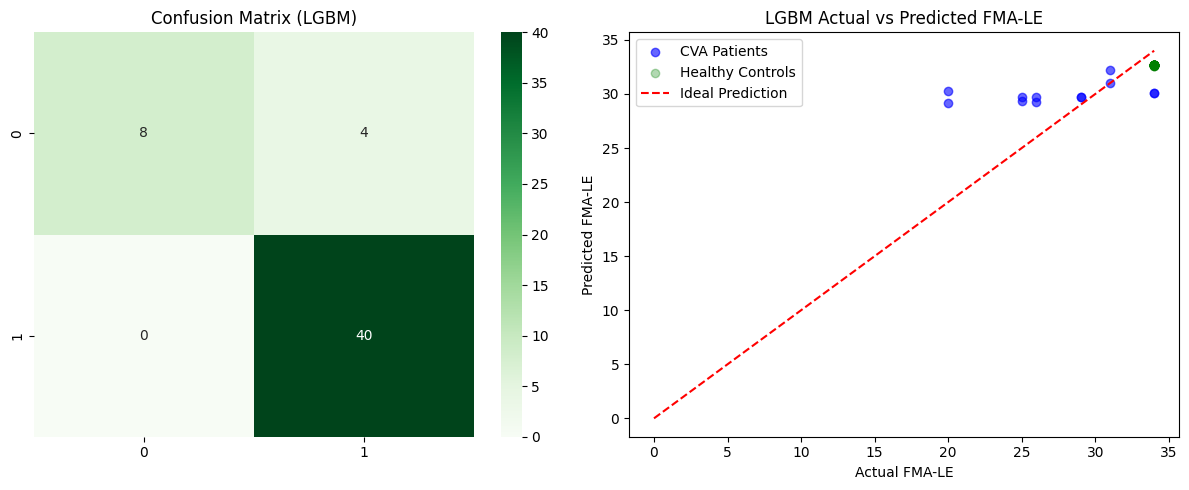

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier, LGBMRegressor # Pustaka LightGBM
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix)

print("=======================================================")
print(" TAHAP 2: LIGHTGBM STRATIFIED TRAINING & DETAIL REPORT")
print("=======================================================\n")

# ==============================================================================
# A. PERSIAPAN DATA & PENYARINGAN
# ==============================================================================
base_dir = r"D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset"
csv_path = os.path.join(base_dir, "dataset_semiogram_final_lengkap.csv")

df = pd.read_csv(csv_path)
df = df.dropna(subset=['FMA_LE'])
df['Subject_ID'] = df['Subject_ID'].astype(str).str.strip()

kolom_identitas_target = ['Subject_ID', 'Trial_ID', 'Label_Sehat', 'FMA_LE', 'Label', 'Subject']
kolom_fitur_murni = [col for col in df.columns if col not in kolom_identitas_target 
                     and not any(x in col.lower() for x in ['zraw', 'zcoef', 'zscore'])]

# ==============================================================================
# B. DIAGNOSTIK & STRATIFIED SPLIT (SUBJECT-WISE)
# ==============================================================================
# 1. Agregasi tingkat subjek
subject_info = df.groupby('Subject_ID').agg(Label=('Label_Sehat', 'first'), Mean_FMA=('FMA_LE', 'mean')).reset_index()

def kategorikan_pasien(row):
    if row['Label'] == 1: return 'Sehat'
    if row['Mean_FMA'] < 15: return 'CVA_Parah'
    elif 15 <= row['Mean_FMA'] <= 25: return 'CVA_Sedang'
    else: return 'CVA_Ringan'

subject_info['Kategori'] = subject_info.apply(kategorikan_pasien, axis=1)

# --- [ REPORT 1: DISTRIBUSI ASLI ] ---
print("-" * 50)
print(" 1. DISTRIBUSI ASLI (TOTAL PASIEN)")
print("-" * 50)
dist_awal = subject_info['Kategori'].value_counts()
for kat in ['Sehat', 'CVA_Ringan', 'CVA_Sedang', 'CVA_Parah']:
    if kat in dist_awal:
        print(f"-> {kat:12}: {dist_awal[kat]} pasien")

# --- [ LOGIKA MUTASI UNTUK MENCEGAH ERROR ] ---
small_classes = dist_awal[dist_awal < 2].index
if not small_classes.empty:
    print("\n[!] MUTASI DETECTED: Menyeimbangkan kategori untuk splitting...")
    for cls in small_classes:
        target = 'CVA_Sedang'
        ids = subject_info[subject_info['Kategori'] == cls]['Subject_ID'].tolist()
        subject_info['Kategori'] = subject_info['Kategori'].replace(cls, target)
        print(f"    - Pasien {ids} dipindah dari {cls} ke {target} (Mencegah Error)")

# 2. Eksekusi Split (Subject-Wise)
subjects = subject_info['Subject_ID'].values
categories = subject_info['Kategori'].values

sub_train, sub_temp, cat_train, cat_temp = train_test_split(
    subjects, categories, test_size=0.20, random_state=42, stratify=categories
)
sub_val, sub_test, cat_val, cat_test = train_test_split(
    sub_temp, cat_temp, test_size=0.50, random_state=42, stratify=cat_temp
)

# 3. Fungsi Laporan Hasil Pembagian
def print_laporan_detail(nama_set, sub_array, df_asli, sub_info_df):
    df_set = df_asli[df_asli['Subject_ID'].isin(sub_array)]
    kondisi_set = sub_info_df[sub_info_df['Subject_ID'].isin(sub_array)]['Kategori'].value_counts()
    print(f"\n[ SEBARAN {nama_set.upper()} ]")
    print(f"-> Total: {len(sub_array)} Pasien | {len(df_set)} Trials")
    for k in ['Sehat', 'CVA_Ringan', 'CVA_Sedang', 'CVA_Parah']:
        if k in kondisi_set:
            print(f"   - {k:12}: {kondisi_set[k]} pasien")
    return df_set

print("\n" + "-" * 50)
print(" 2. LAPORAN PEMBAGIAN DATA SETELAH SPLIT")
print("-" * 50)
df_train = print_laporan_detail("Training (80%)", sub_train, df, subject_info)
df_val = print_laporan_detail("Validation (10%)", sub_val, df, subject_info)
df_test = print_laporan_detail("Testing (10%)", sub_test, df, subject_info)

# Normalisasi & Save Scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[kolom_fitur_murni])
X_val = scaler.transform(df_val[kolom_fitur_murni])
X_test = scaler.transform(df_test[kolom_fitur_murni])
joblib.dump(scaler, os.path.join(base_dir, "scaler_lgbm.pkl"))

y_c_train, y_r_train = df_train['Label_Sehat'].values, df_train['FMA_LE'].values
y_c_val, y_r_val = df_val['Label_Sehat'].values, df_val['FMA_LE'].values
y_c_test, y_r_test = df_test['Label_Sehat'].values, df_test['FMA_LE'].values

# ==============================================================================
# C. TUNING & TRAINING LIGHTGBM
# ==============================================================================
model_lgbm_c_path = os.path.join(base_dir, "best_lgbm_class.pkl")
model_lgbm_r_path = os.path.join(base_dir, "best_lgbm_reg.pkl")

if os.path.exists(model_lgbm_c_path) and os.path.exists(model_lgbm_r_path):
    print("\nModel LightGBM ditemukan! Memuat model...")
    best_lgbm_class = joblib.load(model_lgbm_c_path)
    best_lgbm_reg = joblib.load(model_lgbm_r_path)
else:
    print("\nMemulai Tuning LightGBM...")
    # LGBM butuh tuning pada num_leaves dan min_data_in_leaf agar tidak overfit pada data kecil
    param_grid_lgbm = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [15, 31, 50],
        'min_child_samples': [5, 10, 20],
        'verbose': [-1] # Mengurangi spam log
    }
    
    # Klasifikasi (Handle Imbalance dengan is_unbalance)
    grid_c = GridSearchCV(LGBMClassifier(is_unbalance=True, random_state=42), 
                          param_grid_lgbm, cv=3, n_jobs=-1).fit(X_train, y_c_train)
    best_lgbm_class = grid_c.best_estimator_

    # Regresi
    grid_r = GridSearchCV(LGBMRegressor(random_state=42), 
                          param_grid_lgbm, cv=3, scoring='r2', n_jobs=-1).fit(X_train, y_r_train)
    best_lgbm_reg = grid_r.best_estimator_

    joblib.dump(best_lgbm_class, model_lgbm_c_path)
    joblib.dump(best_lgbm_reg, model_lgbm_r_path)
    print(f"-> Hyperparameter Terbaik (Regresi): {grid_r.best_params_}")

# ==============================================================================
# D. EVALUASI TESTING SET LENGKAP
# ==============================================================================
print("\n" + "=" * 60)
print(" 3. LAPORAN EVALUASI AKHIR (TESTING SET - LGBM)")
print("=" * 60)

pred_c = best_lgbm_class.predict(X_test)
pred_r = best_lgbm_reg.predict(X_test)

# Metrik Klasifikasi
print(f"\n[ METRIK KLASIFIKASI ]")
print(f"Accuracy  : {accuracy_score(y_c_test, pred_c):.4f}")
print(f"Precision : {precision_score(y_c_test, pred_c):.4f}")
print(f"Recall    : {recall_score(y_c_test, pred_c):.4f}")
print(f"F1-Score  : {f1_score(y_c_test, pred_c):.4f}")

# Metrik Regresi
mse = mean_squared_error(y_r_test, pred_r)
r2_global = r2_score(y_r_test, pred_r)
mask_cva = (y_c_test == 0)
mask_hs = (y_c_test == 1)
r2_cva = r2_score(y_r_test[mask_cva], pred_r[mask_cva]) if sum(mask_cva) > 1 else 0
r2_hs = r2_score(y_r_test[mask_hs], pred_r[mask_hs]) if sum(mask_hs) > 1 else 0

print(f"\n[ METRIK REGRESI FMA-LE ]")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {np.sqrt(mse):.4f}")
print(f"MAE       : {mean_absolute_error(y_r_test, pred_r):.4f}")
print(f"R2 Global : {r2_global:.4f} (Gabungan HS+CVA)")
print(f"R2 CVA    : {r2_cva:.4f} (Khusus Pasien Stroke)")
print(f"R2 Sehat  : {r2_hs:.4f} (Validasi Kontrol)")

# Feature Importance Table
df_imp = pd.DataFrame({
    'Fitur': kolom_fitur_murni,
    'Imp_Class': best_lgbm_class.feature_importances_,
    'Imp_Reg': best_lgbm_reg.feature_importances_
}).sort_values(by='Imp_Reg', ascending=False)

print(f"\n[ TABEL KEPENTINGAN FITUR (TOP 10) ]")
display(df_imp.head(10))

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_c_test, pred_c), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (LGBM)")

plt.subplot(1, 2, 2)
plt.scatter(y_r_test[mask_cva], pred_r[mask_cva], label='CVA Patients', color='blue', alpha=0.6)
plt.scatter(y_r_test[mask_hs], pred_r[mask_hs], label='Healthy Controls', color='green', alpha=0.3)
plt.plot([0, 34], [0, 34], 'r--', label='Ideal Prediction')
plt.title("LGBM Actual vs Predicted FMA-LE")
plt.xlabel("Actual FMA-LE"); plt.ylabel("Predicted FMA-LE")
plt.legend(); plt.tight_layout(); plt.show()

Bener 4: SVR

 TAHAP 2: SVM (SVC & SVR) STRATIFIED & DETAIL REPORT

--------------------------------------------------
 1. DISTRIBUSI ASLI (TOTAL PASIEN)
--------------------------------------------------
-> Sehat       : 73 pasien
-> CVA_Ringan  : 30 pasien
-> CVA_Sedang  : 18 pasien
-> CVA_Parah   : 1 pasien

[!] MUTASI DETECTED: Menyeimbangkan kategori untuk splitting...
    - Pasien ['CVA_17'] dipindah dari CVA_Parah ke CVA_Sedang (Mencegah Error)

--------------------------------------------------
 2. LAPORAN PEMBAGIAN DATA SETELAH SPLIT
--------------------------------------------------

[ SEBARAN TRAINING (80%) ]
-> Total: 97 Pasien | 392 Trials
   - Sehat       : 58 pasien
   - CVA_Ringan  : 24 pasien
   - CVA_Sedang  : 15 pasien

[ SEBARAN VALIDATION (10%) ]
-> Total: 12 Pasien | 44 Trials
   - Sehat       : 7 pasien
   - CVA_Ringan  : 3 pasien
   - CVA_Sedang  : 2 pasien

[ SEBARAN TESTING (10%) ]
-> Total: 13 Pasien | 52 Trials
   - Sehat       : 8 pasien
   - CVA_Ringan  : 3 pasien
   - 

,Fitur,Importance_Mean
8,swTr,0.031451
3,Step_Length,0.031198
0,Average_Speed,0.029614
14,P1aCC,0.022404
17,iHRaAP,0.022254
19,iHRaCC,0.022040
2,Step_Count,0.018211
10,CVdstT,0.015790
5,UTurn_Pattern,0.014189
4,UTurn_Steps,0.013396


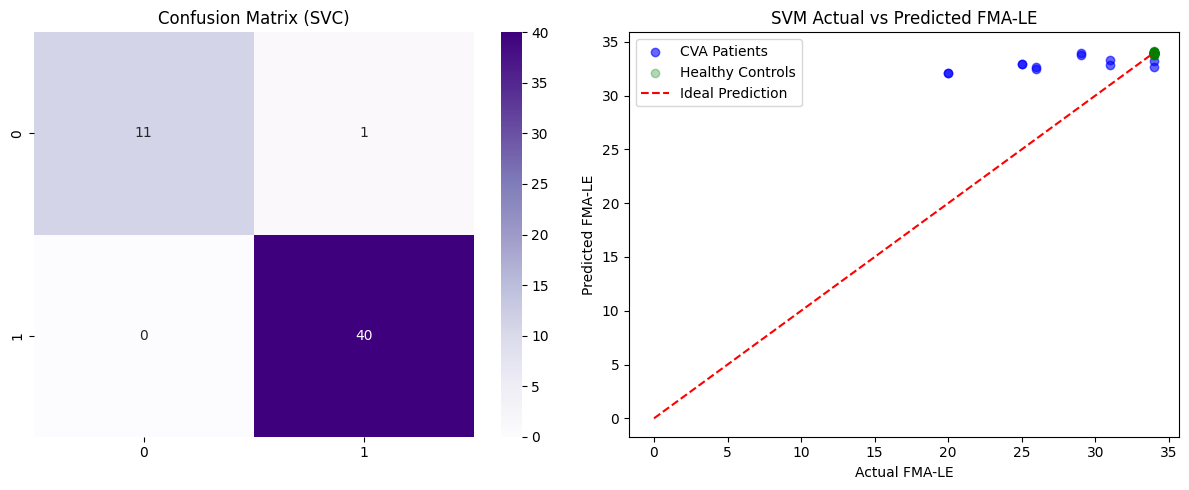

In [2]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC, SVR # Pustaka SVM
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance # Untuk Feature Importance di SVM
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix)

print("=======================================================")
print(" TAHAP 2: SVM (SVC & SVR) STRATIFIED & DETAIL REPORT")
print("=======================================================\n")

# ==============================================================================
# A. PERSIAPAN DATA & PENYARINGAN
# ==============================================================================
base_dir = r"D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset"
csv_path = os.path.join(base_dir, "dataset_semiogram_final_lengkap.csv")

df = pd.read_csv(csv_path)
df = df.dropna(subset=['FMA_LE'])
df['Subject_ID'] = df['Subject_ID'].astype(str).str.strip()

kolom_identitas_target = ['Subject_ID', 'Trial_ID', 'Label_Sehat', 'FMA_LE', 'Label', 'Subject']
kolom_fitur_murni = [col for col in df.columns if col not in kolom_identitas_target 
                     and not any(x in col.lower() for x in ['zraw', 'zcoef', 'zscore'])]

# ==============================================================================
# B. DIAGNOSTIK & STRATIFIED SPLIT (SUBJECT-WISE)
# ==============================================================================
subject_info = df.groupby('Subject_ID').agg(Label=('Label_Sehat', 'first'), Mean_FMA=('FMA_LE', 'mean')).reset_index()

def kategorikan_pasien(row):
    if row['Label'] == 1: return 'Sehat'
    if row['Mean_FMA'] < 15: return 'CVA_Parah'
    elif 15 <= row['Mean_FMA'] <= 25: return 'CVA_Sedang'
    else: return 'CVA_Ringan'

subject_info['Kategori'] = subject_info.apply(kategorikan_pasien, axis=1)

# --- [ REPORT 1: DISTRIBUSI ASLI ] ---
print("-" * 50)
print(" 1. DISTRIBUSI ASLI (TOTAL PASIEN)")
print("-" * 50)
dist_awal = subject_info['Kategori'].value_counts()
for kat in ['Sehat', 'CVA_Ringan', 'CVA_Sedang', 'CVA_Parah']:
    if kat in dist_awal:
        print(f"-> {kat:12}: {dist_awal[kat]} pasien")

# --- [ LOGIKA MUTASI UNTUK MENCEGAH ERROR ] ---
small_classes = dist_awal[dist_awal < 2].index
if not small_classes.empty:
    print("\n[!] MUTASI DETECTED: Menyeimbangkan kategori untuk splitting...")
    for cls in small_classes:
        target = 'CVA_Sedang'
        ids = subject_info[subject_info['Kategori'] == cls]['Subject_ID'].tolist()
        subject_info['Kategori'] = subject_info['Kategori'].replace(cls, target)
        print(f"    - Pasien {ids} dipindah dari {cls} ke {target} (Mencegah Error)")

# Split Pasien (Subject-Wise)
sub_train, sub_temp, cat_train, cat_temp = train_test_split(
    subject_info['Subject_ID'].values, subject_info['Kategori'].values, 
    test_size=0.20, random_state=42, stratify=subject_info['Kategori'].values
)
sub_val, sub_test, cat_val, cat_test = train_test_split(
    sub_temp, cat_temp, test_size=0.50, random_state=42, stratify=cat_temp
)

# Fungsi Laporan Detail
def print_laporan_detail(nama_set, sub_array, df_asli, sub_info_df):
    df_set = df_asli[df_asli['Subject_ID'].isin(sub_array)]
    kondisi_set = sub_info_df[sub_info_df['Subject_ID'].isin(sub_array)]['Kategori'].value_counts()
    print(f"\n[ SEBARAN {nama_set.upper()} ]")
    print(f"-> Total: {len(sub_array)} Pasien | {len(df_set)} Trials")
    for k in ['Sehat', 'CVA_Ringan', 'CVA_Sedang', 'CVA_Parah']:
        if k in kondisi_set: print(f"   - {k:12}: {kondisi_set[k]} pasien")
    return df_set

print("\n" + "-" * 50)
print(" 2. LAPORAN PEMBAGIAN DATA SETELAH SPLIT")
print("-" * 50)
df_train = print_laporan_detail("Training (80%)", sub_train, df, subject_info)
df_val = print_laporan_detail("Validation (10%)", sub_val, df, subject_info)
df_test = print_laporan_detail("Testing (10%)", sub_test, df, subject_info)

# Normalisasi & Save Scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[kolom_fitur_murni])
X_val = scaler.transform(df_val[kolom_fitur_murni])
X_test = scaler.transform(df_test[kolom_fitur_murni])
joblib.dump(scaler, os.path.join(base_dir, "scaler_svm.pkl"))

y_c_train, y_r_train = df_train['Label_Sehat'].values, df_train['FMA_LE'].values
y_c_test, y_r_test = df_test['Label_Sehat'].values, df_test['FMA_LE'].values

# ==============================================================================
# C. TUNING & TRAINING SVM (SVC & SVR)
# ==============================================================================
model_svc_path = os.path.join(base_dir, "best_svc_class.pkl")
model_svr_path = os.path.join(base_dir, "best_svr_reg.pkl")

if os.path.exists(model_svc_path) and os.path.exists(model_svr_path):
    print("\nModel SVM ditemukan! Memuat model...")
    best_svc = joblib.load(model_svc_path)
    best_svr = joblib.load(model_svr_path)
else:
    print("\nMemulai Tuning SVM (SVC & SVR)...")
    # Strategi Tuning: Mencari C (Regulasi) dan Gamma (Fleksibilitas Kernel)
    param_grid_svm = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1],
        'kernel': ['rbf'] # RBF paling superior untuk data nonlinear gait
    }
    
    # Klasifikasi (SVC) - Handle Imbalance dengan class_weight
    grid_svc = GridSearchCV(SVC(class_weight='balanced', random_state=42), 
                            param_grid_svm, cv=3, n_jobs=-1).fit(X_train, y_c_train)
    best_svc = grid_svc.best_estimator_

    # Regresi (SVR)
    grid_svr = GridSearchCV(SVR(epsilon=0.1), # Epsilon menentukan toleransi error
                            param_grid_svm, cv=3, scoring='r2', n_jobs=-1).fit(X_train, y_r_train)
    best_svr = grid_svr.best_estimator_

    joblib.dump(best_svc, model_svc_path)
    joblib.dump(best_svr, model_svr_path)
    print(f"-> Hyperparameter Terbaik (Regresi): {grid_svr.best_params_}")

# ==============================================================================
# D. EVALUASI TESTING SET LENGKAP
# ==============================================================================
print("\n" + "=" * 60)
print(" 3. LAPORAN EVALUASI AKHIR (TESTING SET - SVM)")
print("=" * 60)

pred_c = best_svc.predict(X_test)
pred_r = best_svr.predict(X_test)

# Metrik Klasifikasi
print(f"\n[ METRIK KLASIFIKASI ]")
print(f"Accuracy  : {accuracy_score(y_c_test, pred_c):.4f}")
print(f"Precision : {precision_score(y_c_test, pred_c):.4f}")
print(f"Recall    : {recall_score(y_c_test, pred_c):.4f}")
print(f"F1-Score  : {f1_score(y_c_test, pred_c):.4f}")

# Metrik Regresi
mse = mean_squared_error(y_r_test, pred_r)
r2_global = r2_score(y_r_test, pred_r)
mask_cva = (y_c_test == 0)
mask_hs = (y_c_test == 1)
r2_cva = r2_score(y_r_test[mask_cva], pred_r[mask_cva]) if sum(mask_cva) > 1 else 0
r2_hs = r2_score(y_r_test[mask_hs], pred_r[mask_hs]) if sum(mask_hs) > 1 else 0

print(f"\n[ METRIK REGRESI FMA-LE ]")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {np.sqrt(mse):.4f}")
print(f"MAE       : {mean_absolute_error(y_r_test, pred_r):.4f}")
print(f"R2 Global : {r2_global:.4f} (Gabungan HS+CVA)")
print(f"R2 CVA    : {r2_cva:.4f} (Khusus Pasien Stroke)")
print(f"R2 Sehat  : {r2_hs:.4f} (Validasi Kontrol)")

# --- [ STRATEGI FEATURE IMPORTANCE: PERMUTATION ] ---
print("\nMenghitung Permutation Importance (Mungkin memakan waktu sedikit lama)...")
perm_r = permutation_importance(best_svr, X_test, y_r_test, n_repeats=10, random_state=42)

df_imp = pd.DataFrame({
    'Fitur': kolom_fitur_murni,
    'Importance_Mean': perm_r.importances_mean
}).sort_values(by='Importance_Mean', ascending=False)

print(f"\n[ TABEL KEPENTINGAN FITUR (URUTAN SVR) ]")
display(df_imp.head(10))

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_c_test, pred_c), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix (SVC)")

plt.subplot(1, 2, 2)
plt.scatter(y_r_test[mask_cva], pred_r[mask_cva], label='CVA Patients', color='blue', alpha=0.6)
plt.scatter(y_r_test[mask_hs], pred_r[mask_hs], label='Healthy Controls', color='green', alpha=0.3)
plt.plot([0, 34], [0, 34], 'r--', label='Ideal Prediction')
plt.title("SVM Actual vs Predicted FMA-LE")
plt.xlabel("Actual FMA-LE"); plt.ylabel("Predicted FMA-LE")
plt.legend(); plt.tight_layout(); plt.show()

Bener 5: 1D-CNN

 TAHAP 2: 1D CNN STRATIFIED TRAINING & DETAIL REPORT

Distribusi Asli:
Kategori
Sehat         73
CVA_Ringan    30
CVA_Sedang    18
CVA_Parah      1
Name: count, dtype: int64

[!] Mutasi: Kategori ['CVA_Parah'] digabung ke CVA_Sedang.
Memuat model CNN...

 LAPORAN EVALUASI 1D CNN - TESTING SET

[ KLASIFIKASI ]
Accuracy : 0.9615
Recall   : 1.0000

[ REGRESI ]
MAE      : 27.8105
RMSE     : 27.9857
R2 Global: -63.3387
R2 CVA   : -28.0876

Menghitung Permutation Importance untuk CNN...


,Fitur,Importance
3,Step_Length,0.209478
2,Step_Count,0.203713
15,P2aCC,0.130215
13,LDLJ_A,0.099945
0,Average_Speed,0.088242
14,P1aCC,0.076330
10,CVdstT,0.060807
12,SPARCrot,0.043733
17,iHRaAP,0.043331
7,CVStrT,0.039316


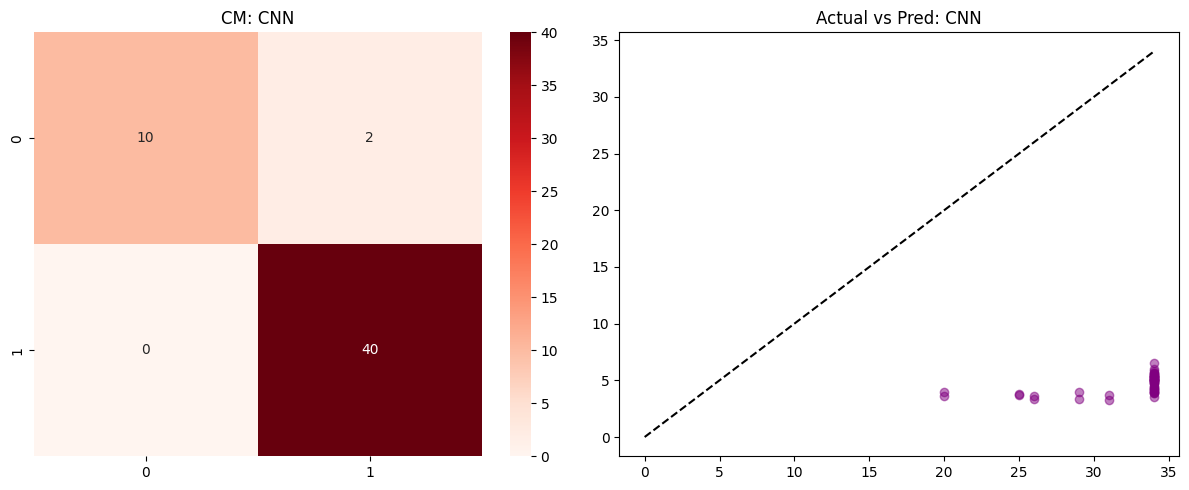

In [5]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix)

print("=======================================================")
print(" TAHAP 2: 1D CNN STRATIFIED TRAINING & DETAIL REPORT")
print("=======================================================\n")

# ==============================================================================
# A. PERSIAPAN DATA & STRATIFIED SPLIT
# ==============================================================================
base_dir = r"D:\Crystaly UI\Sem 6 of BME\Propen\dataset\dataset"
csv_path = os.path.join(base_dir, "dataset_semiogram_final_lengkap.csv")

df = pd.read_csv(csv_path)
df = df.dropna(subset=['FMA_LE'])
df['Subject_ID'] = df['Subject_ID'].astype(str).str.strip()

kolom_identitas_target = ['Subject_ID', 'Trial_ID', 'Label_Sehat', 'FMA_LE', 'Label', 'Subject']
kolom_fitur_murni = [col for col in df.columns if col not in kolom_identitas_target 
                     and not any(x in col.lower() for x in ['zraw', 'zcoef', 'zscore'])]

# Agregasi & Kategorisasi Pasien
subject_info = df.groupby('Subject_ID').agg(Label=('Label_Sehat', 'first'), Mean_FMA=('FMA_LE', 'mean')).reset_index()

def kategorikan_pasien(row):
    if row['Label'] == 1: return 'Sehat'
    if row['Mean_FMA'] < 15: return 'CVA_Parah'
    elif 15 <= row['Mean_FMA'] <= 25: return 'CVA_Sedang'
    else: return 'CVA_Ringan'

subject_info['Kategori'] = subject_info.apply(kategorikan_pasien, axis=1)

# Laporan Distribusi & Mutasi
dist_awal = subject_info['Kategori'].value_counts()
print(f"Distribusi Asli:\n{dist_awal}\n")

small_classes = dist_awal[dist_awal < 2].index
if not small_classes.empty:
    subject_info['Kategori'] = subject_info['Kategori'].replace(small_classes, 'CVA_Sedang')
    print(f"[!] Mutasi: Kategori {list(small_classes)} digabung ke CVA_Sedang.")

# Split 80/10/10
sub_train, sub_temp, cat_train, cat_temp = train_test_split(
    subject_info['Subject_ID'].values, subject_info['Kategori'].values, 
    test_size=0.20, random_state=42, stratify=subject_info['Kategori'].values
)
sub_val, sub_test, cat_val, cat_test = train_test_split(
    sub_temp, cat_temp, test_size=0.50, random_state=42, stratify=cat_temp
)

df_train = df[df['Subject_ID'].isin(sub_train)]
df_val = df[df['Subject_ID'].isin(sub_val)]
df_test = df[df['Subject_ID'].isin(sub_test)]

# Normalisasi & Reshaping untuk CNN
scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[kolom_fitur_murni])
X_val = scaler.transform(df_val[kolom_fitur_murni])
X_test = scaler.transform(df_test[kolom_fitur_murni])

# Ubah ke 3D: (samples, features, 1)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

joblib.dump(scaler, os.path.join(base_dir, "scaler_cnn.pkl"))

y_c_train, y_r_train = df_train['Label_Sehat'].values, df_train['FMA_LE'].values
y_c_val, y_r_val = df_val['Label_Sehat'].values, df_val['FMA_LE'].values
y_c_test, y_r_test = df_test['Label_Sehat'].values, df_test['FMA_LE'].values

# ==============================================================================
# C. BUILDING & TRAINING 1D CNN
# ==============================================================================
def build_cnn(task='classification'):
    model = Sequential([
        Input(shape=(X_train.shape[1], 1)),
        Conv1D(32, kernel_size=3, activation='relu'),
        BatchNormalization(),
        Conv1D(64, kernel_size=3, activation='relu'),
        Dropout(0.2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid' if task=='classification' else 'linear')
    ])
    model.compile(optimizer='adam', 
                  loss='binary_crossentropy' if task=='classification' else 'mse',
                  metrics=['accuracy' if task=='classification' else 'mae'])
    return model

path_cnn_c = os.path.join(base_dir, "best_cnn_class.keras")
path_cnn_r = os.path.join(base_dir, "best_cnn_reg.keras")

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

if os.path.exists(path_cnn_c) and os.path.exists(path_cnn_r):
    print("Memuat model CNN...")
    cnn_class = load_model(path_cnn_c)
    cnn_reg = load_model(path_cnn_r)
else:
    print("Training 1D CNN Klasifikasi...")
    cnn_class = build_cnn(task='classification')
    cnn_class.fit(X_train_cnn, y_c_train, validation_data=(X_val_cnn, y_c_val), 
                  epochs=50, batch_size=16, callbacks=[early_stop], verbose=0)
    
    print("Training 1D CNN Regresi...")
    cnn_reg = build_cnn(task='regression')
    cnn_reg.fit(X_train_cnn, y_r_train, validation_data=(X_val_cnn, y_r_val), 
                epochs=100, batch_size=16, callbacks=[early_stop], verbose=0)
    
    cnn_class.save(path_cnn_c)
    cnn_reg.save(path_cnn_r)

# ==============================================================================
# D. EVALUASI TESTING SET (VERSI FIX ERROR PERMUTATION)
# ==============================================================================
print("\n" + "="*60 + "\n LAPORAN EVALUASI 1D CNN - TESTING SET\n" + "="*60)

# 1. Prediksi Standar
pred_c = (cnn_class.predict(X_test_cnn, verbose=0) > 0.5).astype(int).flatten()
pred_r = cnn_reg.predict(X_test_cnn, verbose=0).flatten()

# 2. Metrik (Tetap Sama)
print(f"\n[ KLASIFIKASI ]\nAccuracy : {accuracy_score(y_c_test, pred_c):.4f}")
print(f"Recall   : {recall_score(y_c_test, pred_c):.4f}")

r2_global = r2_score(y_r_test, pred_r)
mask_cva = (y_c_test == 0)
r2_cva = r2_score(y_r_test[mask_cva], pred_r[mask_cva]) if sum(mask_cva) > 1 else 0

print(f"\n[ REGRESI ]\nMAE      : {mean_absolute_error(y_r_test, pred_r):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_r_test, pred_r)):.4f}")
print(f"R2 Global: {r2_global:.4f}\nR2 CVA   : {r2_cva:.4f}")

# --- [ FIX ERROR START DISINI ] ---

# 3. Wrapper Class agar Keras terlihat seperti Sklearn
class CNNRegressorWrapper:
    def __init__(self, model):
        self.model = model
        self._estimator_type = "regressor" # Memberitahu Sklearn ini model regresi

    def fit(self, X, y):
        pass # Tidak perlu melakukan apa-apa, model sudah ditraining

    def predict(self, X):
        # Konversi ke tensor dan reshape
        X_reshaped = X.reshape(X.shape[0], X.shape[1], 1).astype('float32')
        # Panggil model secara langsung (sebagai fungsi), bukan .predict()
        # Ini lebih cepat dan menghindari overhead retracing di dalam loop
        preds = self.model(X_reshaped, training=False)
        return preds.numpy().flatten()

    def score(self, X, y):
        # Sklearn butuh metode score untuk menghitung baseline importance
        return r2_score(y, self.predict(X))

# Buat objek wrapper
wrapped_cnn = CNNRegressorWrapper(cnn_reg)

print("\nMenghitung Permutation Importance untuk CNN...")
# Sekarang kita masukkan wrapped_cnn (objek), bukan function
perm = permutation_importance(wrapped_cnn, X_test, y_r_test, n_repeats=5, random_state=42)

# Buat Tabel
df_imp = pd.DataFrame({
    'Fitur': kolom_fitur_murni, 
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False)

display(df_imp.head(10))

# Plotting (Tetap Sama)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); sns.heatmap(confusion_matrix(y_c_test, pred_c), annot=True, fmt='d', cmap='Reds'); plt.title("CM: CNN")
plt.subplot(1, 2, 2); plt.scatter(y_r_test, pred_r, color='purple', alpha=0.5); plt.plot([0, 34], [0, 34], 'k--'); plt.title("Actual vs Pred: CNN")
plt.tight_layout(); plt.show()